# Análisis Estadístico — TFGM
## Cinética de Seronegativización de IgG anti-*Strongyloides stercoralis* tras Ivermectina
**Cohorte retrospectiva 2014–2024 · Hospital Central de la Defensa Gómez Ulla · N = 44**

---

| | |
|---|---|
| **Investigador** | Yan Rodríguez Hachimaru |
| **Tutor** | Germán Ramírez Olivencia |
| **Código CEIm** | 80/25 TFG |
| **Fuente de datos** | `BASE_SPSS.xlsx` (44 pacientes × 122 variables) |

---

## Estructura de la notebook

| Bloque | Contenido |
|:------:|:----------|
| **00** | Configuración: imports, paleta de colores, rutas |
| **01** | Carga y validación del dataset analítico |
| **02** | Estadística descriptiva: Tabla 1 + test de normalidad |
| **03** | Figuras 1–5: distribuciones, cinética IgG, outcomes, geografía, correlación |

> **Nota:** Esta notebook trabaja directamente sobre `BASE_SPSS.xlsx`, el dataset analítico
> ya derivado y validado (44 filas × 122 columnas). La construcción de este dataset
> a partir de las hojas crudas (`BASAL`, `SERO`, `EOS`, `MICRO`, `SEG`) se documenta
> en el notebook de ETL (`01_etl_pipeline.ipynb`), que no es necesario ejecutar para
> reproducir este análisis.

---
# BLOQUE 00 — Configuración Global

### ¿Qué hacemos y por qué?

Antes de tocar los datos, configuramos tres cosas:

1. **Importaciones**: cargamos las librerías con sus alias estándar.
2. **Paleta de colores semántica**: cada grupo clínico tiene un color fijo en TODAS las figuras.
3. **Estilo global de matplotlib**: tipografía, resolución, bordes — se aplica a toda figura posterior.

Centralizar aquí la configuración visual tiene una ventaja enorme: si quieres cambiar un color
o una fuente, lo haces en UN sitio y se propaga a las 5+ figuras automáticamente.

In [1]:
# ── 00-A | Importaciones ──────────────────────────────────────────────────
#
# ANATOMÍA:
#   import numpy as np       → Operaciones numéricas (floor, where, nan).
#                               Alias 'np' es convención universal.
#   import pandas as pd      → Manipulación de datos tabulares (DataFrames).
#                               Alias 'pd' también universal.
#   from pathlib import Path → Rutas de archivos multiplataforma.
#                               Path('a') / 'b' funciona en Win/Mac/Linux.
#   matplotlib.pyplot as plt → API de gráficos de matplotlib.
#                               plt.subplots(), plt.show(), plt.savefig().
#   matplotlib.ticker        → Formateadores de ejes (ej: mostrar '%' en ticks).
#   matplotlib.patches.Patch → Crear elementos de leyenda manuales.
#   seaborn as sns           → Gráficos estadísticos sobre matplotlib.
#                               Añade violinplots, heatmaps, etc.
#   scipy.stats              → Tests estadísticos (Shapiro, Mann-Whitney, etc.).

import numpy as np
import pandas as pd
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')  # Silenciar advertencias menores → output limpio

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.patches as mpatches  # Para crear leyendas manuales
from matplotlib.patches import Patch
import seaborn as sns

from scipy import stats as scipy_stats

# display() existe en Jupyter pero no en scripts normales → fallback
try:
    display
except NameError:
    display = print

print(f'📦 pandas  {pd.__version__}')
print(f'📦 numpy   {np.__version__}')
print(f'📦 seaborn {sns.__version__}')

📦 pandas  2.3.3
📦 numpy   2.4.2
📦 seaborn 0.13.2


#### 🔬 Anatomía de 00-A — ¿Por qué estos alias?

| Línea | Qué hace | Por qué |
|-------|----------|---------|
| `import numpy as np` | Carga NumPy | Sin alias escribirías `numpy.floor(...)` cada vez. `np` es universal — cualquier tutorial, paper o Stack Overflow lo usa |
| `import pandas as pd` | Carga pandas | Ídem. `pd.DataFrame`, `pd.read_excel` — reconocible al instante |
| `from pathlib import Path` | Rutas de archivos | `Path('data') / 'archivo.xlsx'` funciona en Windows, Mac y Linux sin preocuparte por `\\` vs `/` |
| `warnings.filterwarnings('ignore')` | Silencia warnings | Algunos cálculos con NaN lanzan `RuntimeWarning`. No son errores, pero ensucian el output |
| `import matplotlib.pyplot as plt` | API de gráficos | `plt.subplots()` crea figuras, `plt.show()` las muestra, `plt.savefig()` las guarda |
| `import matplotlib.patches as mpatches` | Parches para leyendas | Cuando la leyenda no sale sola del gráfico, creamos "parches" coloreados manualmente |
| `import seaborn as sns` | Gráficos estadísticos | Construido sobre matplotlib. Añade `sns.heatmap`, `sns.violinplot`, etc. con menos código |
| `from scipy import stats` | Tests estadísticos | Shapiro-Wilk, Mann-Whitney, Fisher, Spearman — todo vive aquí |

In [2]:
# ── 00-B | Paleta de colores semántica ────────────────────────────────────
#
# CONCEPTO CLAVE:
#   En lugar de elegir colores ad-hoc en cada figura, definimos UN diccionario
#   donde cada clave tiene significado clínico. Si en la Figura 3 usas
#   PAL['seroneg'], ves el mismo azul que en la Figura 1.
#
#   Ventaja: cambiar un color aquí lo cambia en TODAS las figuras.
#
# CRITERIOS DE SELECCIÓN:
#   - Daltonismo-safe: evitamos rojo/verde puros juntos.
#   - Legibles en B/N: diferentes luminosidades para impresión.
#   - Semánticos: rojo=riesgo, azul=referencia, ámbar=destacado.
#
# ╔══════════════════════════════════════════════════════════════╗
# ║  PARA CAMBIAR UN COLOR: modifica solo este diccionario.     ║
# ║  Todas las figuras se actualizarán automáticamente.         ║
# ╚══════════════════════════════════════════════════════════════╝

PAL = {
    # ── Grupos principales (estratificación del estudio) ──
    'seroneg'       : '#1565C0',   # Azul marino  → Seronegativización (evento)
    'no_seroneg'    : '#E65100',   # Naranja      → No seroneg / censurado

    # ── Estado inmunológico ──
    'inmuno_dep'    : '#D32F2F',   # Rojo oscuro  → Inmunodeprimido
    'inmuno_comp'   : '#1565C0',   # Azul marino  → Inmunocompetente

    # ── Origen geográfico ──
    'ecuador'       : '#E65100',   # Naranja      → Ecuador
    'sudamerica'    : '#1565C0',   # Azul marino  → Sudamérica
    'otro_origen'   : '#546E7A',   # Gris azulado → Otro origen

    # ── Eosinofilia ──
    'eos_si'        : '#2E7D32',   # Verde oscuro → Eosinofilia presente
    'eos_no'        : '#9E9E9E',   # Gris neutro  → Sin eosinofilia

    # ── IgG basal ──
    'igg_alta'      : '#6A1B9A',   # Púrpura      → IgG basal alta (≥mediana)
    'igg_baja'      : '#00838F',   # Cian oscuro  → IgG basal baja (<mediana)

    # ── Elementos neutros y destacados ──
    'neutral'       : '#37474F',   # Gris carbón  → textos, ejes
    'highlight'     : '#F9A825',   # Ámbar        → líneas de corte, alertas
}

print('🎨 Paleta semántica definida:')
for k, v in PAL.items():
    print(f'   {k:<16} {v}')

🎨 Paleta semántica definida:
   seroneg          #1565C0
   no_seroneg       #E65100
   inmuno_dep       #D32F2F
   inmuno_comp      #1565C0
   ecuador          #E65100
   sudamerica       #1565C0
   otro_origen      #546E7A
   eos_si           #2E7D32
   eos_no           #9E9E9E
   igg_alta         #6A1B9A
   igg_baja         #00838F
   neutral          #37474F
   highlight        #F9A825


In [3]:
# ── 00-C | Configuración visual global de matplotlib ─────────────────────
#
# CONCEPTO CLAVE:
#   plt.rcParams es un diccionario global que controla TODOS los aspectos
#   visuales de matplotlib. Lo que configures aquí se aplica a toda figura
#   que hagas después en esta sesión de Jupyter.
#
#   Es como CSS para gráficos: defines el "tema" una vez y se hereda.
#
# ╔══════════════════════════════════════════════════════════════╗
# ║  PARA CAMBIAR EL ESTILO GLOBAL: modifica este diccionario.  ║
# ║  Para cambiar UNA figura concreta, usa ax.set_*() local.    ║
# ╚══════════════════════════════════════════════════════════════╝

plt.rcParams.update({
    # ── Tipografía ──
    'font.family'       : 'sans-serif',
    'font.sans-serif'   : ['Arial', 'Helvetica', 'DejaVu Sans'],
    'font.size'         : 11,            # Tamaño base de texto
    'axes.titlesize'    : 13,            # Títulos de ejes
    'axes.titleweight'  : 'bold',
    'axes.labelsize'    : 11,            # Etiquetas de ejes (xlabel, ylabel)
    'xtick.labelsize'   : 10,            # Números en eje X
    'ytick.labelsize'   : 10,            # Números en eje Y
    'legend.fontsize'   : 10,
    'legend.framealpha' : 0.9,           # Transparencia del fondo de la leyenda

    # ── Resolución ──
    'figure.dpi'        : 150,           # Pantalla (Jupyter)
    'savefig.dpi'       : 300,           # Guardado (estándar para journals)

    # ── Fondo ──
    'figure.facecolor'  : 'white',
    'axes.facecolor'    : 'white',

    # ── Bordes (spines) ──
    'axes.spines.top'   : False,         # Sin borde superior → estética moderna
    'axes.spines.right' : False,         # Sin borde derecho

    # ── Grid ──
    'axes.grid'         : True,
    'grid.alpha'        : 0.3,
    'grid.color'        : '#CCCCCC',
    'grid.linewidth'    : 0.7,

    # ── Líneas ──
    'lines.linewidth'   : 2.0,
})

# ── Directorios de salida ────────────────────────────────────────────────
OUT = Path('outputs')
for sub in ['figures', 'tables']:
    (OUT / sub).mkdir(parents=True, exist_ok=True)

# ── Ruta al dataset ──────────────────────────────────────────────────────
# ╔══════════════════════════════════════════════════════════════╗
# ║  AJUSTA ESTA RUTA si tu archivo está en otra carpeta.       ║
# ╚══════════════════════════════════════════════════════════════╝
DATA_PATH = Path('BASE_SPSS.xlsx')

print('✅ Configuración visual aplicada')
print(f'📁 Figuras en:  {(OUT / "figures").resolve()}')
print(f'📁 Tablas en:   {(OUT / "tables").resolve()}')
print(f'📊 Dataset en:  {DATA_PATH.resolve()}')

✅ Configuración visual aplicada
📁 Figuras en:  /Users/yanrodriguez/Desktop/VSCode/TFGM_Strongyloides/outputs/figures
📁 Tablas en:   /Users/yanrodriguez/Desktop/VSCode/TFGM_Strongyloides/outputs/tables
📊 Dataset en:  /Users/yanrodriguez/Desktop/VSCode/TFGM_Strongyloides/BASE_SPSS.xlsx


#### 🔬 Anatomía de 00-C — ¿Qué hace cada parámetro de `rcParams`?

**`axes.spines.top = False`** y **`axes.spines.right = False`:**
Eliminan los bordes superior y derecho de cada gráfico. Es una convención de estilo moderna (Tufte, *The Visual Display of Quantitative Information*): menos tinta, más claridad.

**`figure.dpi = 150` vs `savefig.dpi = 300`:**
`dpi` = dots per inch (resolución). En pantalla, 150 es suficiente y mantiene Jupyter rápido. Al guardar con `plt.savefig()`, usamos 300 — el mínimo que piden los journals biomédicos.

**`axes.grid = True` con `grid.alpha = 0.3`:**
El grid (rejilla de fondo) ayuda a leer valores exactos, pero con alpha bajo (semitransparente) no compite visualmente con los datos.

**`Path('outputs')` con `mkdir(parents=True, exist_ok=True)`:**
`parents=True` crea carpetas intermedias si no existen. `exist_ok=True` no da error si ya existe. Así puedes re-ejecutar la celda sin problemas.

---
# BLOQUE 01 — Carga y Validación del Dataset Analítico

### ¿Qué hacemos y por qué?

Cargamos `BASE_SPSS.xlsx` — el dataset analítico con **una fila por paciente** y 122 variables
ya derivadas (demográficas, serológicas a cada timepoint, outcomes, etc.).

Antes de analizar, verificamos que los datos son los esperados:
- ¿44 pacientes? ¿122 columnas? ¿28 eventos de seronegativización?
- ¿Los conteos cuadran con el cuaderno de variables?

Esto se llama **assertion testing** — si algo falla, la notebook se detiene aquí
en vez de producir resultados silenciosamente incorrectos.

In [4]:
# ── 01-A | Carga del dataset analítico ────────────────────────────────────
#
# pd.read_excel() lee el archivo .xlsx completo.
# Internamente usa la librería openpyxl (para .xlsx) o xlrd (para .xls).
#
# El resultado es un DataFrame — la estructura central de pandas:
#   - Cada fila = un paciente (ID 1 a 44)
#   - Cada columna = una variable (EDAD_DX, IGG_BASAL, EVENT_SERONEG...)
#   - df.shape devuelve (n_filas, n_columnas)

df = pd.read_excel(DATA_PATH)

# ── Validaciones de integridad ───────────────────────────────────────────
# assert CONDICIÓN, "mensaje de error"
# Si la condición es False, Python lanza AssertionError con el mensaje.
# Es como un "freno de emergencia" — mejor fallar aquí que obtener
# resultados erróneos 500 líneas más abajo.

assert len(df) == 44,              f"Se esperan 44 filas, hay {len(df)}"
assert df['ID'].nunique() == 44,   "IDs duplicados detectados"
assert (df['EVENT_SERONEG'] == 1).sum() == 28, "Se esperan 28 eventos de seroneg."

# ── Definir los dos grupos de comparación ────────────────────────────────
# Estos DataFrames filtrados se reutilizan en TODAS las celdas siguientes.
# G_SERONEG: pacientes que tuvieron seronegativización (EVENT=1)
# G_CENS:    pacientes censurados o sin seronegativización (EVENT=0)

G_SERONEG = df[df['EVENT_SERONEG'] == 1]   # n = 28
G_CENS    = df[df['EVENT_SERONEG'] == 0]   # n = 16

print(f"✅ Dataset cargado: {df.shape[0]} pacientes × {df.shape[1]} variables")
print(f"   Seronegativización (evento):   n = {len(G_SERONEG)}")
print(f"   Censurados / sin seroneg.:     n = {len(G_CENS)}")
print(f"   Seguimiento mediano (todos):   {df['TIME_TO_SERONEG_M'].median():.1f} meses")
print(f"   Seguimiento máximo:            {df['TIME_TO_SERONEG_M'].max():.1f} meses")

✅ Dataset cargado: 44 pacientes × 122 variables
   Seronegativización (evento):   n = 28
   Censurados / sin seroneg.:     n = 16
   Seguimiento mediano (todos):   5.7 meses
   Seguimiento máximo:            72.1 meses


In [5]:
# ── 01-B | Validaciones cruzadas detalladas ───────────────────────────────
#
# Comparamos los valores calculados con los esperados del cuaderno de variables.
# Este patrón de "tabla de checks" es muy útil en proyectos reales:
# si alguien modifica el Excel y un conteo cambia, lo detectas aquí.

checks = [
    ('N pacientes',                     len(df),                                     44),
    ('IDs únicos',                      df['ID'].nunique(),                          44),
    ('Eventos seroneg',                 int(df['EVENT_SERONEG'].sum()),              28),
    ('Censurados',                      int((df['EVENT_SERONEG'] == 0).sum()),       16),
    ('Sin TIME (excluir KM)',           int(df['TIME_TO_SERONEG_M'].isna().sum()),    4),
    ('INMUNO_DICO=1 (inmunodep)',       int((df['INMUNO_DICO'] == 1).sum()),          4),
    ('COMORB_INMUNO=1 (inmuno-afect)',  int((df['COMORB_INMUNO'] == 1).sum()),       15),
    ('Ecuador (ORIGEN_DICO=1)',         int((df['ORIGEN_DICO'] == 1).sum()),         15),
    ('Sudamérica (ORIGEN_DICO2=1)',     int((df['ORIGEN_DICO2'] == 1).sum()),        36),
    ('IGG_BASAL con dato',              int(df['IGG_BASAL'].notna().sum()),          36),
    ('T_RESID ≤10a',                    int((df['T_RESID_DICO'] == 1).sum()),        11),
    ('T_RESID >10a',                    int((df['T_RESID_DICO'] == 2).sum()),        29),
    ('RECIDIVA_BIN=1',                  int((df['RECIDIVA_BIN'] == 1).sum()),         4),
]

print(f"  {'Check':<40} {'Obtenido':>9}  {'Esperado':>9}  OK")
print('  ' + '─' * 64)
all_ok = True
for nombre, obtenido, esperado in checks:
    ok = '✅' if obtenido == esperado else '❌'
    if obtenido != esperado:
        all_ok = False
    print(f"  {nombre:<40} {obtenido:>9}  {esperado:>9}  {ok}")

print()
if all_ok:
    print('✅ Todas las validaciones correctas.')
else:
    print('❌ Hay discrepancias — revisar el dataset.')

  Check                                     Obtenido   Esperado  OK
  ────────────────────────────────────────────────────────────────
  N pacientes                                     44         44  ✅
  IDs únicos                                      44         44  ✅
  Eventos seroneg                                 28         28  ✅
  Censurados                                      16         16  ✅
  Sin TIME (excluir KM)                            4          4  ✅
  INMUNO_DICO=1 (inmunodep)                        4          4  ✅
  COMORB_INMUNO=1 (inmuno-afect)                  15         15  ✅
  Ecuador (ORIGEN_DICO=1)                         15         15  ✅
  Sudamérica (ORIGEN_DICO2=1)                     36         36  ✅
  IGG_BASAL con dato                              36         36  ✅
  T_RESID ≤10a                                    11         11  ✅
  T_RESID >10a                                    29         29  ✅
  RECIDIVA_BIN=1                                   4         

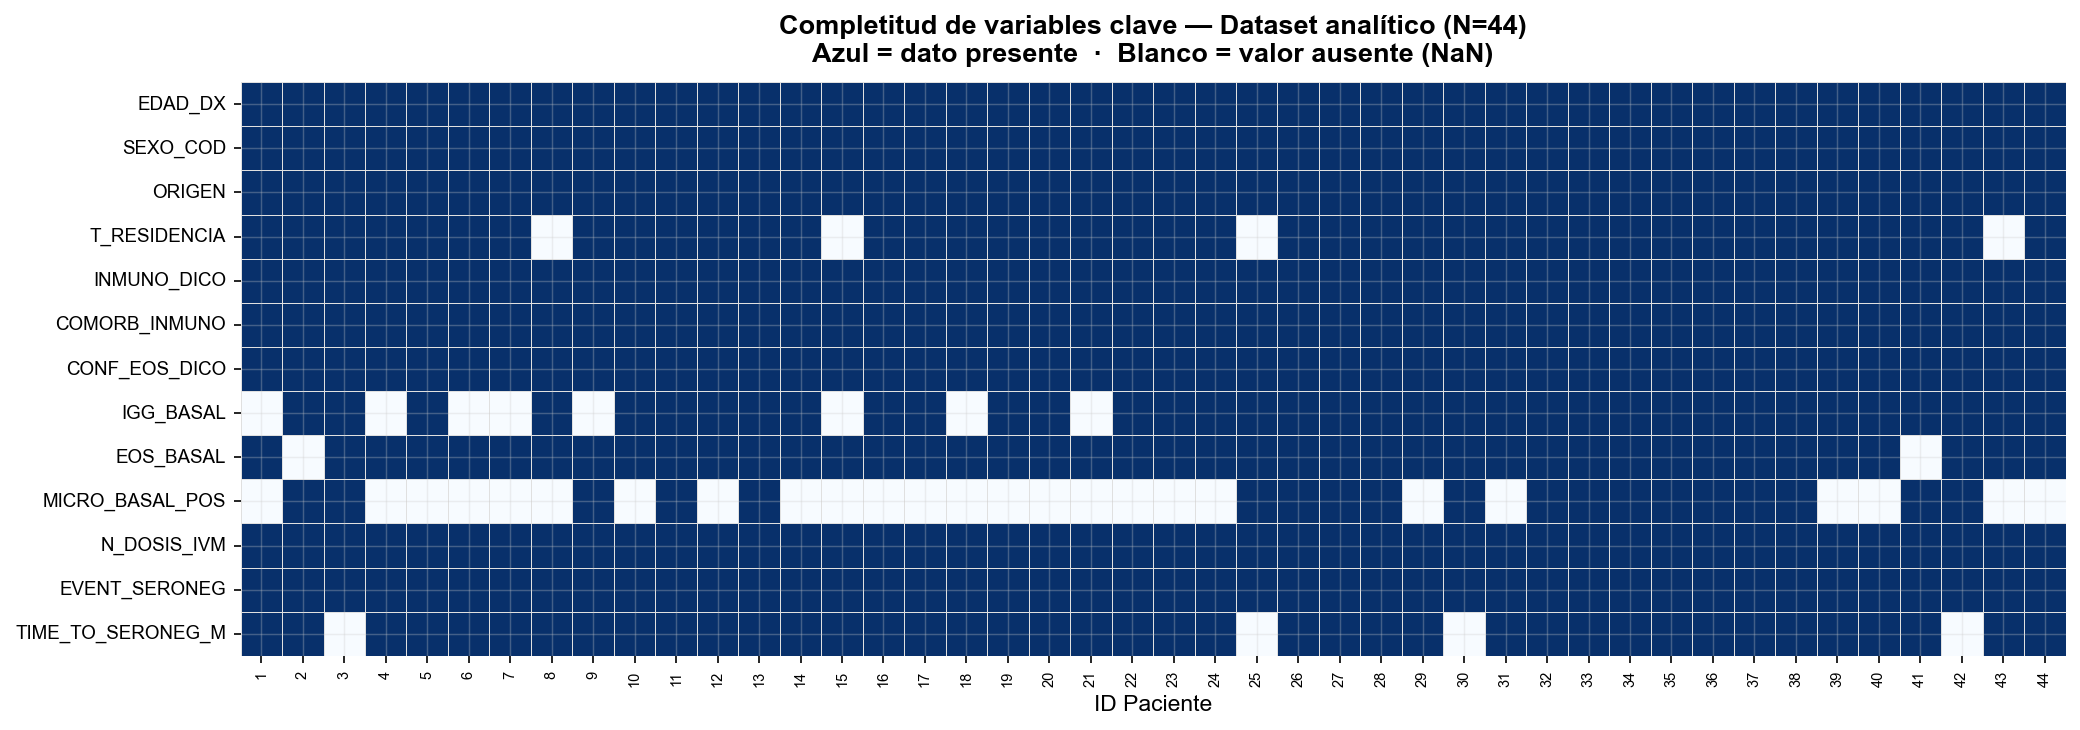

💾 Guardado en outputs/figures/fig00_missing_map.png


In [6]:
# ── 01-C | Mapa visual de completitud — variables clave ──────────────────
#
# CONCEPTO: Un heatmap binario donde azul = dato presente, blanco = NaN.
# Permite ver de un vistazo qué pacientes tienen datos incompletos.
#
# ANATOMÍA:
#   df[cols].notna()        → DataFrame de booleanos (True donde hay dato)
#   .astype(int)            → Convierte True/False a 1/0 (seaborn necesita números)
#   .T                      → Transpone: variables en eje Y, pacientes en eje X
#   sns.heatmap(...)        → Dibuja la matriz como mapa de calor
#     cmap='Blues'           → Escala de azules (0=blanco, 1=azul oscuro)
#     vmin=0, vmax=1         → Fija el rango (sin esto, si todo fuera 1, no habría contraste)
#     cbar=False             → Sin barra de color (es binario, no la necesitamos)
#     linewidths=0.4         → Separación entre celdas

# Seleccionar variables clave para el mapa (no las 122)
KEY_COLS = [
    'EDAD_DX', 'SEXO_COD', 'ORIGEN', 'T_RESIDENCIA',
    'INMUNO_DICO', 'COMORB_INMUNO', 'CONF_EOS_DICO',
    'IGG_BASAL', 'EOS_BASAL', 'MICRO_BASAL_POS',
    'N_DOSIS_IVM', 'EVENT_SERONEG', 'TIME_TO_SERONEG_M',
]

fig, ax = plt.subplots(figsize=(14, 5))

mask = df[KEY_COLS].notna().astype(int)
sns.heatmap(
    mask.T,
    cmap='Blues',
    vmin=0, vmax=1,
    cbar=False,
    linewidths=0.4,
    linecolor='#E0E0E0',
    ax=ax,
    yticklabels=KEY_COLS,
    xticklabels=df['ID'].astype(int),
)

ax.set_title(
    'Completitud de variables clave — Dataset analítico (N=44)\n'
    'Azul = dato presente  ·  Blanco = valor ausente (NaN)',
    pad=10
)
ax.set_xlabel('ID Paciente')
ax.set_ylabel('')
ax.tick_params(axis='x', labelsize=7, rotation=90)
ax.tick_params(axis='y', labelsize=9)

plt.tight_layout()
plt.savefig(OUT / 'figures' / 'fig00_missing_map.png', bbox_inches='tight')
plt.show()
print('💾 Guardado en outputs/figures/fig00_missing_map.png')

---
# BLOQUE 02 — Estadística Descriptiva: Tabla 1 y Normalidad

### ¿Qué hacemos y por qué?

La **Tabla 1** es obligatoria en cualquier estudio clínico. Resume las características basales
de la cohorte, estratificadas por el outcome principal (seronegativización sí/no).

Antes de decidir qué test usar, comprobamos la normalidad de las variables continuas
con **Shapiro-Wilk** — el test más potente para n < 50.

**Regla de decisión:**
- Si p > 0.05 en Shapiro → asumimos normalidad → media ± DE + t de Student
- Si p ≤ 0.05 → no normal → mediana (IQR) + Mann-Whitney U

In [7]:
# ── 02-A | Test de normalidad (Shapiro-Wilk) ─────────────────────────────
#
# CONCEPTO:
#   Shapiro-Wilk contrasta H₀: "los datos provienen de una distribución normal".
#   Si p < 0.05, rechazamos H₀ → los datos NO son normales.
#   Consecuencia: usamos mediana/IQR (no media/DE) y Mann-Whitney (no t-test).
#
# ANATOMÍA:
#   scipy_stats.shapiro(vals)  → devuelve (W, p-valor)
#   W es el estadístico del test (0 a 1; cuanto más cerca de 1, más normal).

# ╔══════════════════════════════════════════════════════════════╗
# ║  VARIABLES CONTINUAS: modifica esta lista para añadir/quitar ║
# ╚══════════════════════════════════════════════════════════════╝
CONT_VARS = [
    ('EDAD_DX',           'Edad al diagnóstico (años)'),
    ('T_RESIDENCIA',      'Tiempo residencia España (años)'),
    ('IGG_BASAL',         'IgG basal (índice)'),
    ('EOS_BASAL',         'Eosinófilos basales (10³/µL)'),
    ('TIME_TO_SERONEG_M', 'Tiempo hasta seroneg. (meses)*'),
]

print(f"{'Variable':<35}  {'n':>4}  {'W':>7}  {'p-valor':>8}  {'Distribución'}")
print('─' * 72)
for col, label in CONT_VARS:
    vals = df[col].dropna()
    stat, p = scipy_stats.shapiro(vals)
    dist = 'Normal' if p > 0.05 else 'No normal ⚠️'
    print(f"{label:<35}  {len(vals):>4}  {stat:.4f}  {p:>8.4f}  {dist}")

print()
print("→ Conclusión: todas las variables excepto EDAD_DX son no normales.")
print("  Justificación para usar mediana (IQR) y Mann-Whitney en toda la Tabla 1.")

Variable                                n        W   p-valor  Distribución
────────────────────────────────────────────────────────────────────────
Edad al diagnóstico (años)             44  0.9826    0.7376  Normal
Tiempo residencia España (años)        40  0.9292    0.0152  No normal ⚠️
IgG basal (índice)                     36  0.8714    0.0006  No normal ⚠️
Eosinófilos basales (10³/µL)           42  0.8085    0.0000  No normal ⚠️
Tiempo hasta seroneg. (meses)*         40  0.6407    0.0000  No normal ⚠️

→ Conclusión: todas las variables excepto EDAD_DX son no normales.
  Justificación para usar mediana (IQR) y Mann-Whitney en toda la Tabla 1.


In [8]:
# ── 02-B | Tabla 1: Características basales por seronegativización ────────
#
# ANATOMÍA DE LA TABLA 1:
#   Para cada variable:
#     - Continuas: mediana (Q1–Q3) → test de Mann-Whitney U bilateral
#     - Categóricas: n (%) → chi-cuadrado o Fisher exacto si celda esperada < 5
#
# ╔══════════════════════════════════════════════════════════════╗
# ║  VARIABLES CATEGÓRICAS: modifica esta lista para cambiar     ║
# ║  las variables y sus categorías que aparecen en la Tabla 1.  ║
# ╚══════════════════════════════════════════════════════════════╝

CAT_VARS = [
    ('SEXO_LABEL',           'Sexo',                         ['Mujer', 'Varón']),
    ('ORIGEN_DICO_LABEL',    'Origen Ecuador vs. Otro',      ['Ecuador', 'Otro']),
    ('ORIGEN_DICO2_LABEL',   'Origen Sudamérica vs. Otro',   ['Sudamérica', 'Otro']),
    ('T_RESID_LABEL',        'Residencia ≤10 vs. >10 años',  ['≤10 años', '>10 años']),
    ('INMUNO_LABEL',         'Estado inmune',                 ['Inmunocompetente', 'Inmunodeprimido']),
    ('COMORB_INMUNO_LABEL',  'Comorbilidad inmunológica',     ['Sin comorbilidad', 'Afecta sist. inmune', 'Sin efecto inmune']),
    ('N_DOSIS_IVM',          'Pauta ivermectina',             ['MONO', 'DOBLE_CONSECUTIVA', 'DOBLE_SEPARADA', 'CUADRUPLE']),
    ('EOS_BASAL_BIN',        'Eosinofilia basal (>500/µL)',   [1.0, 2.0]),
    ('MICRO_BASAL_POS',      'Microscopia basal positiva',    [1.0, 0.0]),
    ('DIAG_METODO_LABEL',    'Método diagnóstico',
     ['Solo serología', 'Sero + Micro', 'Solo microbiológica', 'Sin confirmar pre-TTO']),
]

STRAT = 'EVENT_SERONEG'

# ── Funciones auxiliares ─────────────────────────────────────────────────

def fmt_median_iqr(series):
    """Formatea como 'mediana (Q1–Q3)'. Devuelve 'NA' si no hay datos."""
    v = series.dropna()
    if len(v) == 0:
        return 'NA'
    return f"{v.median():.1f} ({v.quantile(.25):.1f}–{v.quantile(.75):.1f})"

def mwu_p(s1, s2):
    """Mann-Whitney U bilateral. Devuelve NaN si n < 2 en algún grupo."""
    s1, s2 = s1.dropna(), s2.dropna()
    if len(s1) < 2 or len(s2) < 2:
        return np.nan
    _, p = scipy_stats.mannwhitneyu(s1, s2, alternative='two-sided')
    return p

def cat_p(col):
    """p-valor para variable categórica: chi² o Fisher si celdas < 5."""
    ct = pd.crosstab(df[col].dropna(), df.loc[df[col].notna(), STRAT])
    if ct.shape[0] < 2 or ct.shape[1] < 2:
        return np.nan
    # Frecuencias esperadas → si alguna < 5 y es tabla 2×2, usamos Fisher
    expected = scipy_stats.chi2_contingency(ct)[3]
    if (expected < 5).any() and ct.shape == (2, 2):
        _, p = scipy_stats.fisher_exact(ct)
    else:
        _, p, _, _ = scipy_stats.chi2_contingency(ct)
    return p

def fmt_p(p):
    """Formato de p-valor para tabla."""
    if pd.isna(p):
        return ''
    if p < 0.001:
        return '<0.001'
    return f"{p:.3f}"

# ── Construir filas de la tabla ──────────────────────────────────────────
rows = []

# Sección continuas
rows.append({'Variable': '─── Variables continuas ───',
             'Total': '', 'Seroneg (n=28)': '', 'Censurado (n=16)': '', 'p': ''})

for col, label in CONT_VARS:
    p = mwu_p(G_SERONEG[col], G_CENS[col])
    n_tot = df[col].notna().sum()
    rows.append({
        'Variable': f"  {label}",
        'Total': f"{fmt_median_iqr(df[col])}  (n={n_tot})",
        'Seroneg (n=28)': fmt_median_iqr(G_SERONEG[col]),
        'Censurado (n=16)': fmt_median_iqr(G_CENS[col]),
        'p': fmt_p(p),
    })

# Sección categóricas
rows.append({'Variable': '─── Variables categóricas ───',
             'Total': '', 'Seroneg (n=28)': '', 'Censurado (n=16)': '', 'p': ''})

for col, label, cats in CAT_VARS:
    n_valid = df[col].notna().sum()
    p = cat_p(col)
    first = True
    for cat in cats:
        n_c  = (df[col] == cat).sum()
        n_c1 = (G_SERONEG[col] == cat).sum()
        n_c0 = (G_CENS[col] == cat).sum()
        pct  = n_c / n_valid * 100 if n_valid > 0 else 0
        pct1 = n_c1 / G_SERONEG[col].notna().sum() * 100 if G_SERONEG[col].notna().sum() > 0 else 0
        pct0 = n_c0 / G_CENS[col].notna().sum() * 100 if G_CENS[col].notna().sum() > 0 else 0
        lbl_str = f"  {label}" if first else f"    ↳ {cat}"
        rows.append({
            'Variable': lbl_str,
            'Total': f"{n_c} ({pct:.1f}%)",
            'Seroneg (n=28)': f"{n_c1} ({pct1:.1f}%)",
            'Censurado (n=16)': f"{n_c0} ({pct0:.1f}%)",
            'p': fmt_p(p) if first else '',
        })
        first = False

tabla1 = pd.DataFrame(rows).set_index('Variable')
display(tabla1)  # Jupyter renderiza como tabla HTML

# Guardar
tabla1.to_csv(OUT / 'tables' / 'tabla1_descriptiva.csv', encoding='utf-8-sig')
print('💾 Guardada en outputs/tables/tabla1_descriptiva.csv')

,Total,Seroneg (n=28),Censurado (n=16),p
Variable,,,,
─── Variables continuas ───,,,,
Edad al diagnóstico (años),47.0 (36.0–56.0) (n=44),47.5 (34.0–54.2),46.5 (37.5–60.0),0.435
Tiempo residencia España (años),18.0 (9.0–20.0) (n=40),18.0 (11.0–19.5),20.0 (9.0–21.0),0.417
IgG basal (índice),3.1 (1.3–6.6) (n=36),1.7 (1.2–3.4),6.5 (3.6–7.2),0.002
Eosinófilos basales (10³/µL),0.8 (0.2–1.2) (n=42),0.4 (0.2–1.0),1.0 (0.7–1.6),0.068
Tiempo hasta seroneg. (meses)*,5.7 (2.8–11.0) (n=40),7.0 (3.2–11.0),2.9 (2.0–13.2),0.452
─── Variables categóricas ───,,,,
Sexo,25 (56.8%),14 (50.0%),11 (68.8%),0.373
↳ Varón,19 (43.2%),14 (50.0%),5 (31.2%),


💾 Guardada en outputs/tables/tabla1_descriptiva.csv


#### 🔬 Anatomía de la Tabla 1

**`pd.crosstab(col, strat)`:**
Construye una tabla de contingencia 2D. Las filas son las categorías de `col` y las columnas los valores del estratificador (0/1). Es exactamente el input que necesitan `chi2_contingency` y `fisher_exact`.

**¿Por qué Fisher y no siempre chi²?**
El chi-cuadrado es una aproximación que funciona bien con muestras grandes. La regla de Cochran dice: si alguna frecuencia *esperada* es < 5, la aproximación falla. Con N=44 y categorías poco frecuentes, esto pasa a menudo → cambiamos a Fisher exacto (que calcula la probabilidad exacta, no una aproximación).

**`fmt_median_iqr(series)`:**
Recibe una Serie de pandas, elimina los NaN con `.dropna()`, y devuelve el texto formateado "mediana (Q1–Q3)". El `.quantile(.25)` calcula el percentil 25 (primer cuartil, Q1).

---
# BLOQUE 03 — Figuras

Cada celda genera una figura autocontenida:
1. **Figura 1** — Distribución de variables continuas por grupo (violin + boxplot)
2. **Figura 2** — Cinética de IgG post-tratamiento (trayectorias + mediana)
3. **Figura 3** — Comparativa de definiciones de seronegativización (lollipop)
4. **Figura 4** — Distribución geográfica de la cohorte (barras + donut)
5. **Figura 5** — IgG basal vs. tiempo hasta seronegativización (scatter + Spearman)

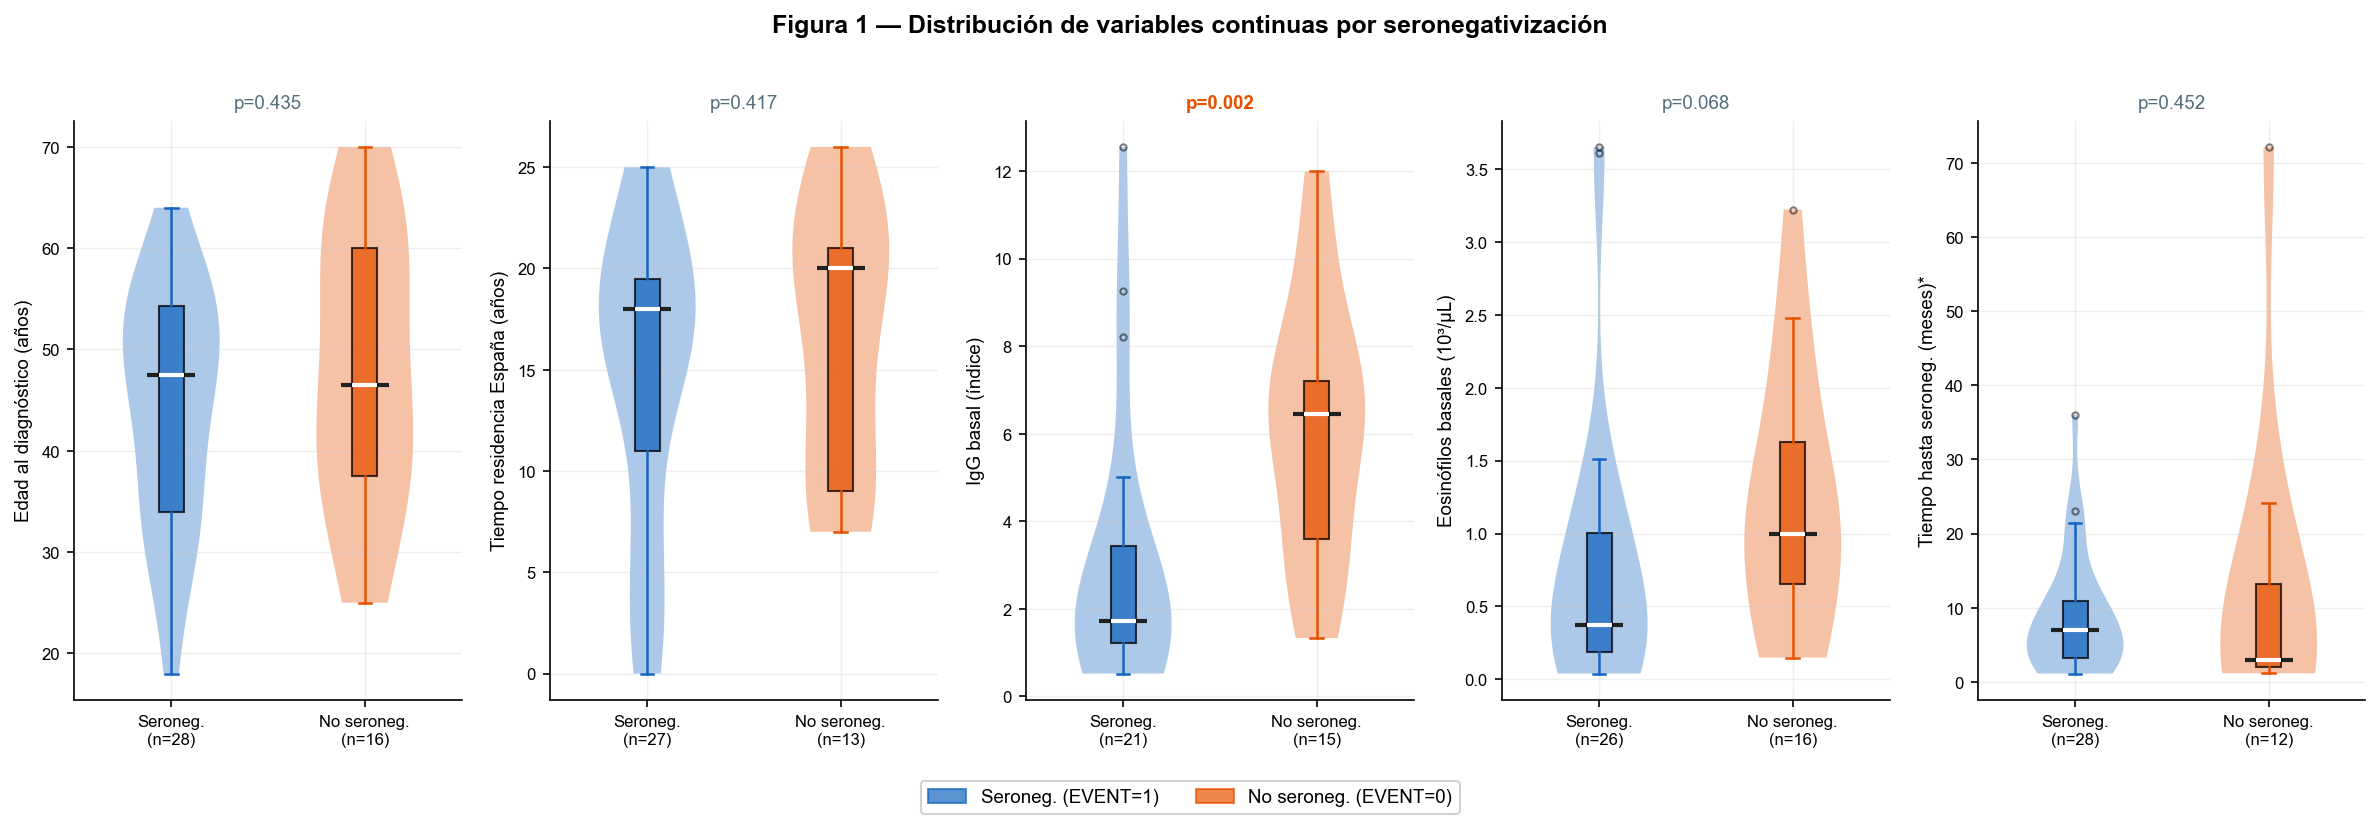

💾 Guardada en outputs/figures/fig01_continuas_por_evento.png


In [9]:
# ── 03-A | Figura 1: Violin + boxplot para variables continuas ────────────
#
# CONCEPTO:
#   Combinamos dos tipos de gráfico para cada variable:
#   - VIOLÍN: muestra la FORMA de la distribución (¿bimodal? ¿asimétrica?)
#     El ancho del violín a cada altura = densidad de datos en ese rango.
#   - BOXPLOT: muestra mediana, cuartiles y outliers de forma precisa.
#   Juntos se complementan: el violín da forma, el boxplot da números.
#
# ANATOMÍA:
#   fig, axes = plt.subplots(1, 5, ...)  → Crea 1 fila × 5 columnas de gráficos.
#     fig = la "hoja de papel" completa.
#     axes = array de 5 ejes (cada uno es un gráfico independiente).
#
#   ax.violinplot([data1, data2], positions=[1, 2])
#     positions = dónde poner cada violín en el eje X.
#     showmedians=True dibuja una línea horizontal en la mediana.
#
#   ax.boxplot(data, positions=[pos], widths=0.13, patch_artist=True)
#     widths=0.13 → estrecho para no tapar el violín.
#     patch_artist=True → permite colorear el interior de la caja.

fig, axes = plt.subplots(1, 5, figsize=(16, 5))

for ax, (col, label) in zip(axes, CONT_VARS):
    # Datos de cada grupo (sin NaN)
    data_s = G_SERONEG[col].dropna()
    data_n = G_CENS[col].dropna()

    # ── Violín ──
    parts = ax.violinplot(
        [data_s, data_n],
        positions=[1, 2],
        showmedians=True,
        showextrema=False   # Sin las líneas min/max del violín (el boxplot ya las tiene)
    )
    # Colorear cada mitad del violín
    for pc, c in zip(parts['bodies'], [PAL['seroneg'], PAL['no_seroneg']]):
        pc.set_facecolor(c)
        pc.set_alpha(0.35)
    parts['cmedians'].set_color('#212121')
    parts['cmedians'].set_linewidth(2)

    # ── Boxplot superpuesto ──
    for pos, d, c in zip([1, 2], [data_s, data_n], [PAL['seroneg'], PAL['no_seroneg']]):
        ax.boxplot(
            d, positions=[pos], widths=0.13,
            patch_artist=True,
            boxprops=dict(facecolor=c, alpha=0.75),
            medianprops=dict(color='white', linewidth=2),
            whiskerprops=dict(color=c, linewidth=1.2),
            capprops=dict(color=c, linewidth=1.2),
            flierprops=dict(marker='o', color=c, markersize=3, alpha=0.5),
        )

    # ── p-valor de Mann-Whitney ──
    p = mwu_p(data_s, data_n)
    p_str = f'p={p:.3f}' if p >= 0.001 else 'p<0.001'
    color_p = '#E65100' if p < 0.05 else '#546E7A'
    ax.set_title(p_str, fontsize=9, color=color_p,
                 fontweight='bold' if p < 0.05 else 'normal')

    # ── Ejes ──
    ax.set_xticks([1, 2])
    ax.set_xticklabels(
        [f'Seroneg.\n(n={len(data_s)})', f'No seroneg.\n(n={len(data_n)})'],
        fontsize=8,
    )
    ax.set_ylabel(label, fontsize=9)
    ax.tick_params(axis='y', labelsize=8)

# ── Leyenda global ──
patches = [
    mpatches.Patch(color=PAL['seroneg'], alpha=0.7, label='Seroneg. (EVENT=1)'),
    mpatches.Patch(color=PAL['no_seroneg'], alpha=0.7, label='No seroneg. (EVENT=0)'),
]
fig.legend(handles=patches, loc='upper center', bbox_to_anchor=(0.5, 0), ncol=2, fontsize=9)
fig.suptitle(
    'Figura 1 — Distribución de variables continuas por seronegativización',
    fontsize=12, fontweight='bold', y=1.01,
)

plt.tight_layout()
plt.savefig(OUT / 'figures' / 'fig01_continuas_por_evento.png', dpi=300, bbox_inches='tight')
plt.show()
print('💾 Guardada en outputs/figures/fig01_continuas_por_evento.png')

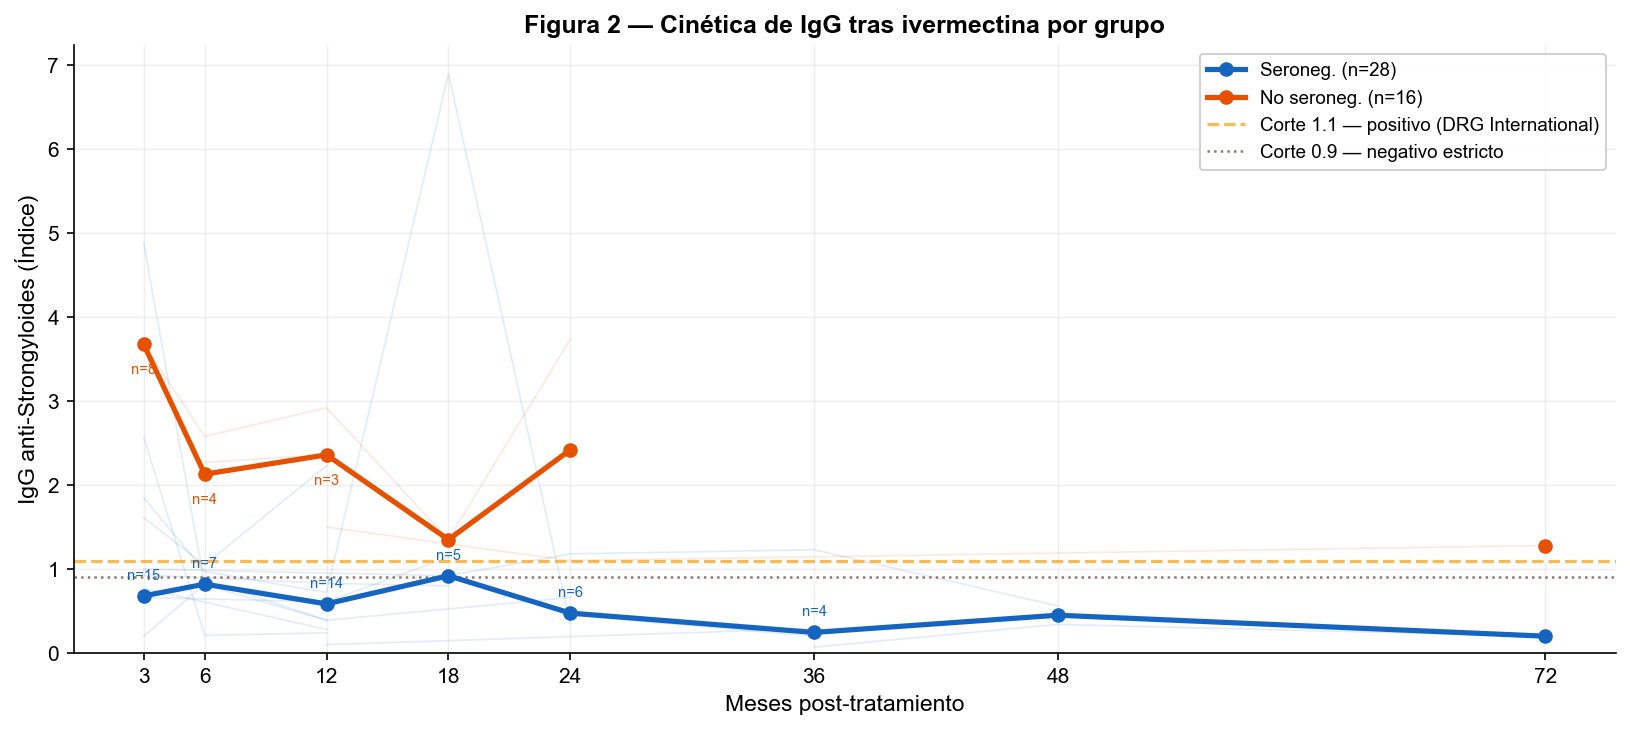

💾 Guardada en outputs/figures/fig02_cinetica_igg.png


In [10]:
# ── 03-B | Figura 2: Cinética de IgG post-tratamiento ────────────────────
#
# CONCEPTO:
#   Gráfico de "spaghetti plot" + mediana grupal.
#   - Líneas finas (alpha=0.12): trayectoria individual de cada paciente.
#     Crean una "nube" que muestra la variabilidad real.
#   - Línea gruesa: mediana del grupo en cada timepoint.
#     Resume la tendencia central.
#   - Líneas horizontales de corte: umbrales clínicos de positividad.
#
# ANATOMÍA:
#   IGG_COLS = columnas tipo 'IGG_M3_CUANTI', 'IGG_M6_CUANTI', ...
#   TIMEPOINTS = los meses correspondientes [3, 6, 12, 18, 24, 36, 48, 72]
#
#   Para cada paciente:
#     row[c] = valor de IgG en el timepoint c (o NaN si no hay dato).
#     Filtramos los NaN para dibujar solo los puntos con dato.
#
#   ax.annotate(f'n={n}', ...) → Anota cuántos pacientes tienen dato en cada punto.
#     Esto es OBLIGATORIO en estudios longitudinales: el lector debe saber
#     que la mediana a 72 meses se basa en 2 pacientes, no en 44.

IGG_COLS   = [c for c in df.columns if c.startswith('IGG_M') and c.endswith('_CUANTI')]
TIMEPOINTS = [3, 6, 12, 18, 24, 36, 48, 72]

fig, ax = plt.subplots(figsize=(11, 5))

for ev, color, label in [
    (1, PAL['seroneg'],    'Seroneg. (n=28)'),
    (0, PAL['no_seroneg'], 'No seroneg. (n=16)'),
]:
    sub = df[df['EVENT_SERONEG'] == ev]

    # Trayectorias individuales (alpha bajo = semitransparente)
    for _, row in sub.iterrows():
        vals = [row[c] for c in IGG_COLS]
        mask = [pd.notna(v) for v in vals]
        t_m = [t for t, m in zip(TIMEPOINTS, mask) if m]
        v_m = [v for v, m in zip(vals, mask) if m]
        if t_m:
            ax.plot(t_m, v_m, color=color, alpha=0.12, linewidth=0.8)

    # Mediana del grupo (línea gruesa)
    medians  = [sub[c].median() for c in IGG_COLS]
    n_per_tp = [sub[c].notna().sum() for c in IGG_COLS]
    ax.plot(TIMEPOINTS, medians, color=color, linewidth=2.5, label=label,
            marker='o', markersize=6, zorder=5)

    # Etiquetas de n en cada timepoint (solo si n ≥ 3 → evitar ruido)
    for tp, med, n in zip(TIMEPOINTS, medians, n_per_tp):
        if pd.notna(med) and n >= 3:
            offset_y = 8 if ev == 1 else -14
            ax.annotate(f'n={n}', (tp, med),
                        textcoords='offset points', xytext=(0, offset_y),
                        fontsize=7, color=color, ha='center')

# ── Líneas de corte clínico ──
ax.axhline(1.1, color=PAL['highlight'], linestyle='--', linewidth=1.5,
           alpha=0.8, label='Corte 1.1 — positivo (DRG International)')
ax.axhline(0.9, color='#795548', linestyle=':', linewidth=1.2,
           alpha=0.8, label='Corte 0.9 — negativo estricto')

ax.set_xlabel('Meses post-tratamiento', fontsize=11)
ax.set_ylabel('IgG anti-Strongyloides (Índice)', fontsize=11)
ax.set_title('Figura 2 — Cinética de IgG tras ivermectina por grupo',
             fontsize=12, fontweight='bold')
ax.set_xticks(TIMEPOINTS)
ax.legend(fontsize=9, loc='upper right')
ax.set_ylim(bottom=0)

plt.tight_layout()
plt.savefig(OUT / 'figures' / 'fig02_cinetica_igg.png', dpi=300, bbox_inches='tight')
plt.show()
print('💾 Guardada en outputs/figures/fig02_cinetica_igg.png')

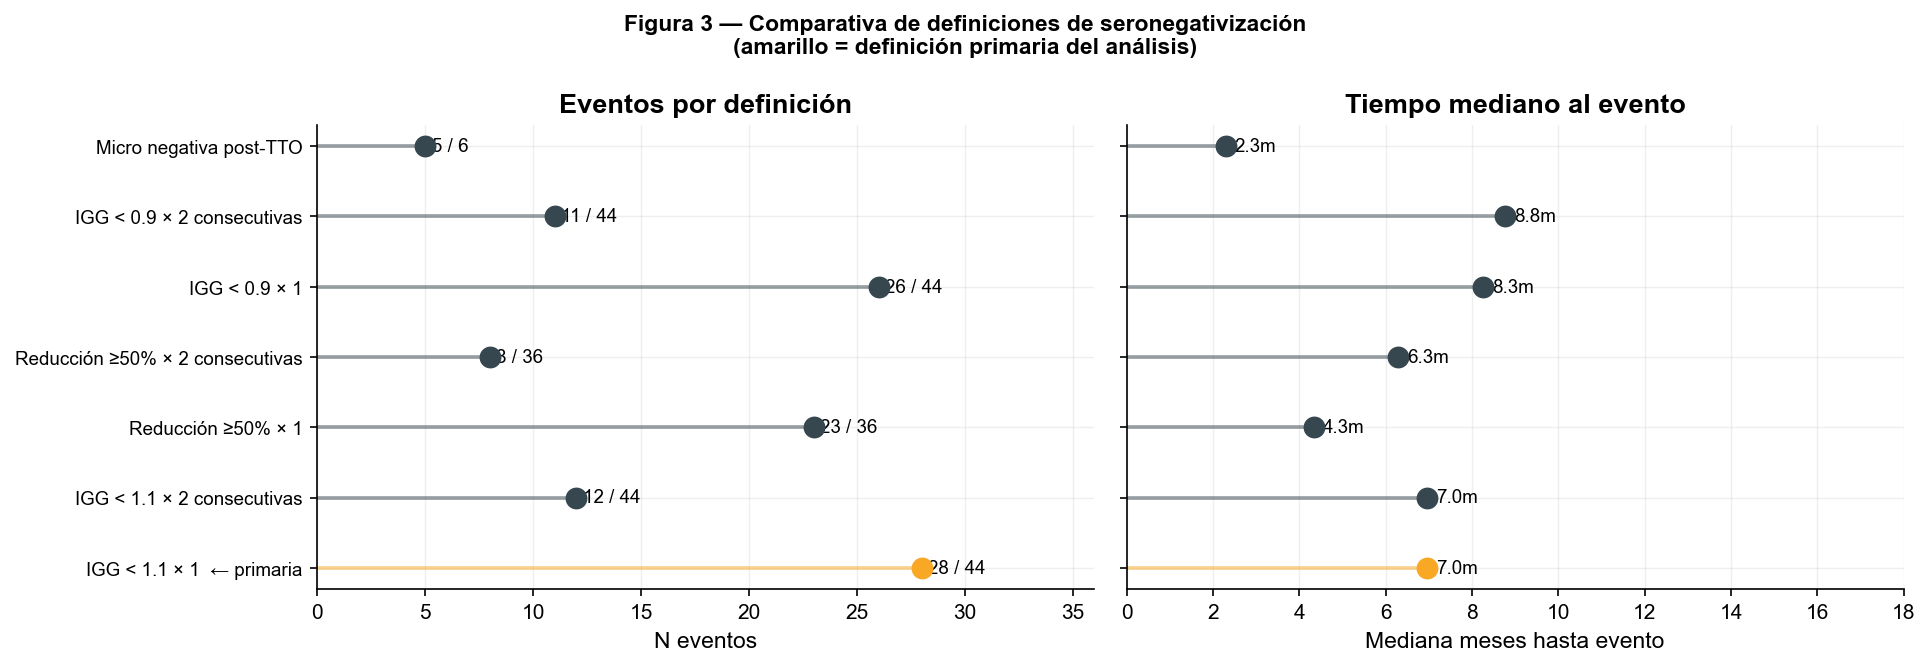

💾 Guardada en outputs/figures/fig03_outcomes_comparativa.png


In [11]:
# ── 03-C | Figura 3: Comparativa de definiciones de seronegativización ────
#
# CONCEPTO:
#   El estudio evalúa VARIAS definiciones de seronegativización.
#   Este gráfico "lollipop" compara cuántos eventos produce cada definición
#   y cuál es el tiempo mediano hasta el evento.
#
#   Lollipop chart: alternativa más limpia al gráfico de barras.
#   - Línea horizontal desde 0 hasta el valor
#   - Punto al final del valor
#   - Reduce el "ratio tinta/dato" (principio de Tufte)
#
# ANATOMÍA:
#   fig, (ax1, ax2) = plt.subplots(1, 2, sharey=True)
#     sharey=True → ambos paneles comparten el eje Y.
#     Si uno se invierte (invert_yaxis), el otro también.
#
# ╔══════════════════════════════════════════════════════════════╗
# ║  DEFINICIONES DE OUTCOME: modifica esta lista para añadir    ║
# ║  o quitar definiciones alternativas.                         ║
# ╚══════════════════════════════════════════════════════════════╝

OUTCOME_DEFS = [
    # (col_evento, col_tiempo, etiqueta, n_denominador)
    ('EV_SERO_11_1X', 'T_SERO_11_1X',  'IGG < 1.1 × 1  ← primaria',      44),
    ('EV_SERO_11_2X', 'T_SERO_11_2X',  'IGG < 1.1 × 2 consecutivas',     44),
    ('EV_50PCT_1X',   'T_50PCT_1X',    'Reducción ≥50% × 1',             36),
    ('EV_50PCT_2X',   'T_50PCT_2X',    'Reducción ≥50% × 2 consecutivas', 36),
    ('EV_SERO_09_1X', 'T_SERO_09_1X',  'IGG < 0.9 × 1',                  44),
    ('EV_SERO_09_2X', 'T_SERO_09_2X',  'IGG < 0.9 × 2 consecutivas',     44),
    ('EV_MICRO_NEG',  'T_MICRO_NEG',   'Micro negativa post-TTO',          6),
]

labels = [d[2] for d in OUTCOME_DEFS]
n_ev   = [(df[d[0]] == 1).sum() for d in OUTCOME_DEFS]
n_dat  = [d[3] for d in OUTCOME_DEFS]
med_t  = [df[df[d[0]] == 1][d[1]].median() for d in OUTCOME_DEFS]
y      = list(range(len(OUTCOME_DEFS)))
colors = [PAL['highlight'] if i == 0 else PAL['neutral'] for i in y]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4.5), sharey=True)

# Panel A: N eventos
for yi, (n, c) in enumerate(zip(n_ev, colors)):
    ax1.plot([0, n], [yi, yi], color=c, linewidth=1.8, alpha=0.5)
    ax1.scatter(n, yi, color=c, s=90, zorder=5)
    ax1.text(n + 0.3, yi, f'{n} / {n_dat[yi]}', va='center', fontsize=9)
ax1.set_yticks(y)
ax1.set_yticklabels(labels, fontsize=9)
ax1.set_xlabel('N eventos')
ax1.set_title('Eventos por definición', fontweight='bold')
ax1.set_xlim(0, 36)
ax1.invert_yaxis()

# Panel B: Mediana del tiempo al evento
for yi, (t, c) in enumerate(zip(med_t, colors)):
    if pd.notna(t):
        ax2.plot([0, t], [yi, yi], color=c, linewidth=1.8, alpha=0.5)
        ax2.scatter(t, yi, color=c, s=90, zorder=5)
        ax2.text(t + 0.2, yi, f'{t:.1f}m', va='center', fontsize=9)
ax2.set_xlabel('Mediana meses hasta evento')
ax2.set_title('Tiempo mediano al evento', fontweight='bold')
ax2.set_xlim(0, 18)
ax2.invert_yaxis()

fig.suptitle(
    'Figura 3 — Comparativa de definiciones de seronegativización\n'
    '(amarillo = definición primaria del análisis)',
    fontsize=11, fontweight='bold',
)
plt.tight_layout()
plt.savefig(OUT / 'figures' / 'fig03_outcomes_comparativa.png', dpi=300, bbox_inches='tight')
plt.show()
print('💾 Guardada en outputs/figures/fig03_outcomes_comparativa.png')

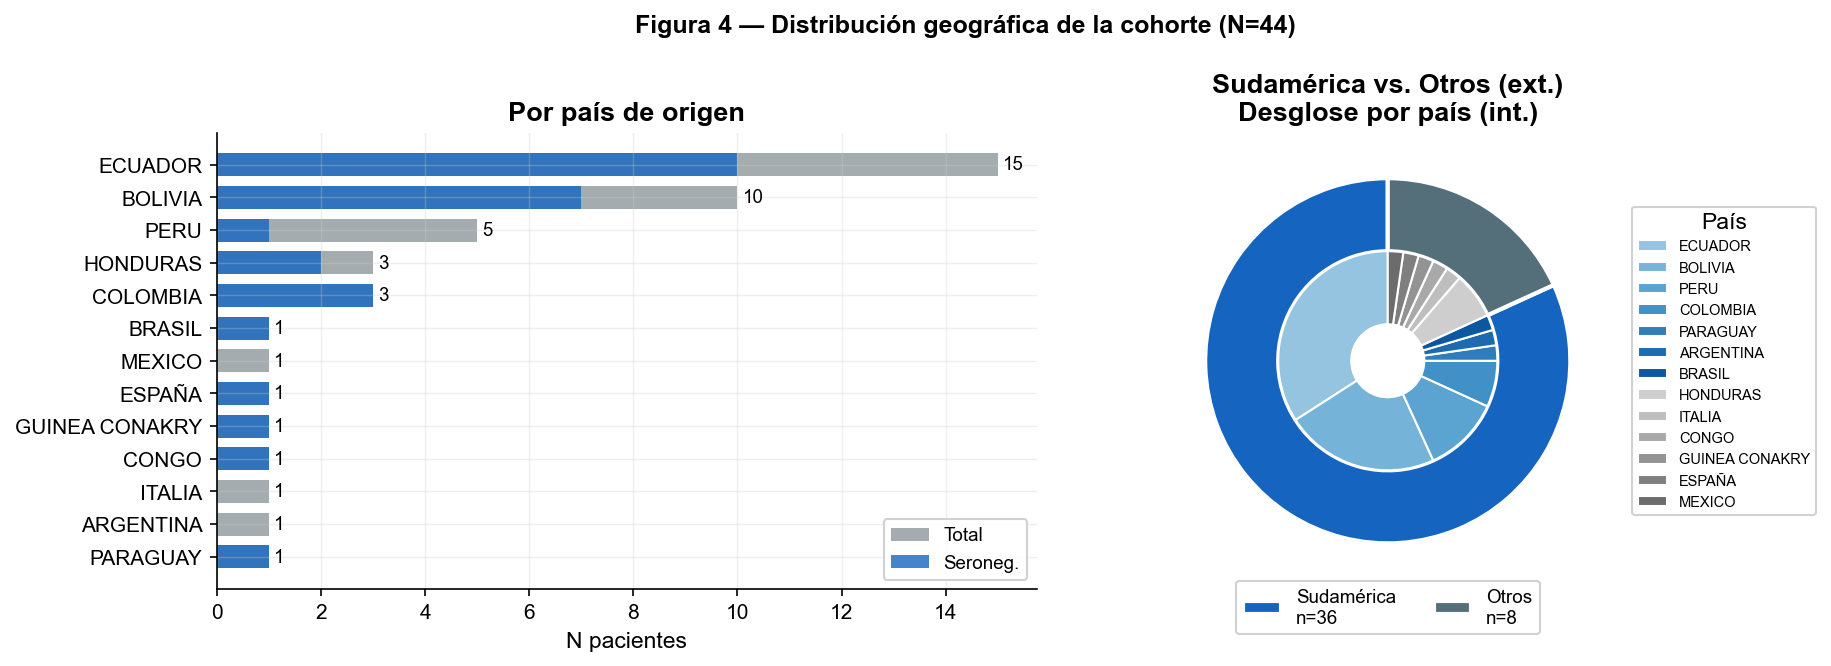

💾 Guardada en outputs/figures/fig04_origen_geografico.png


In [12]:
# ── 03-D | Figura 4: Distribución geográfica ─────────────────────────────
#
# CONCEPTO:
#   Panel A: barras horizontales por país, con superposición de los que tuvieron seroneg.
#     La barra gris = total de ese país.
#     La barra coloreada superpuesta = cuántos de ellos tuvieron seroneg.
#
#   Panel B: donut chart (pie con agujero).
#     Anillo externo: Sudamérica vs. Otros.
#     Anillo interno: desglose por país.
#
# ANATOMÍA:
#   ax.barh() → barras horizontales (h = horizontal).
#     height=0.7 → grosor de la barra.
#     alpha=0.45 → semitransparente (para que se vea la barra superpuesta).
#
#   ax.pie() → gráfico circular.
#     radius=1.0 / 0.6 → anillo externo / interno.
#     wedgeprops=dict(width=0.4) → grosor del anillo (pie - width = agujero).

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

# ── Panel A: barras por país ──
origen_total   = df['ORIGEN'].value_counts().sort_values()
origen_seroneg = G_SERONEG['ORIGEN'].value_counts()

ax = axes[0]
bar_total = ax.barh(
    origen_total.index, origen_total.values,
    color=PAL['neutral'], alpha=0.45, height=0.7, label='Total',
)
ax.barh(
    origen_total.index,
    [origen_seroneg.get(o, 0) for o in origen_total.index],
    color=PAL['seroneg'], alpha=0.8, height=0.7, label='Seroneg.',
)
for bar, n in zip(bar_total, origen_total.values):
    ax.text(bar.get_width() + 0.1, bar.get_y() + bar.get_height() / 2,
            str(n), va='center', fontsize=9)
ax.set_xlabel('N pacientes')
ax.set_title('Por país de origen', fontweight='bold')
ax.legend(fontsize=9)

# ── Panel B: donut Sudamérica vs. Otro ──
ax2 = axes[1]

n_sa   = (df['ORIGEN_DICO2'] == 1).sum()
n_otro = (df['ORIGEN_DICO2'] == 2).sum()

# Anillo externo
outer_sizes  = [n_sa, n_otro]
outer_colors = [PAL['sudamerica'], PAL['otro_origen']]
outer_labels = [f'Sudamérica\nn={n_sa}', f'Otros\nn={n_otro}']

# Anillo interno: desglose por país (sin labels en el gráfico → van a leyenda)
pais_sa   = df[df['ORIGEN_DICO2'] == 1]['ORIGEN'].value_counts()
pais_otro = df[df['ORIGEN_DICO2'] == 2]['ORIGEN'].value_counts()
inner_sizes  = list(pais_sa.values) + list(pais_otro.values)
inner_labels = list(pais_sa.index)  + list(pais_otro.index)

# Colores degradados para cada anillo
blues = plt.cm.Blues(np.linspace(0.4, 0.85, len(pais_sa)))
grays = plt.cm.Greys(np.linspace(0.3, 0.65, len(pais_otro)))
inner_colors = list(blues) + list(grays)

wedges_out, _ = ax2.pie(
    outer_sizes, radius=1.0, colors=outer_colors,
    wedgeprops=dict(width=0.4, edgecolor='white', linewidth=2),
    startangle=90,
)
# Sin labels en el anillo interno para evitar superposición; países en leyenda
wedges_in, _ = ax2.pie(
    inner_sizes, radius=0.6, colors=inner_colors,
    wedgeprops=dict(width=0.4, edgecolor='white', linewidth=1),
    startangle=90,
)
ax2.set_title('Sudamérica vs. Otros (ext.)\nDesglose por país (int.)', fontweight='bold')
# Leyenda anillo externo (debajo)
leg_outer = ax2.legend(wedges_out, outer_labels, loc='lower center',
                       bbox_to_anchor=(0.5, -0.12), ncol=2, fontsize=9)
ax2.add_artist(leg_outer)
# Leyenda países (derecha): evita superposición en porciones pequeñas
ax2.legend(wedges_in, inner_labels, loc='center left', bbox_to_anchor=(1.02, 0.5),
          fontsize=7, title='País')

fig.suptitle('Figura 4 — Distribución geográfica de la cohorte (N=44)',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig(OUT / 'figures' / 'fig04_origen_geografico.png', dpi=300, bbox_inches='tight')
plt.show()
print('💾 Guardada en outputs/figures/fig04_origen_geografico.png')

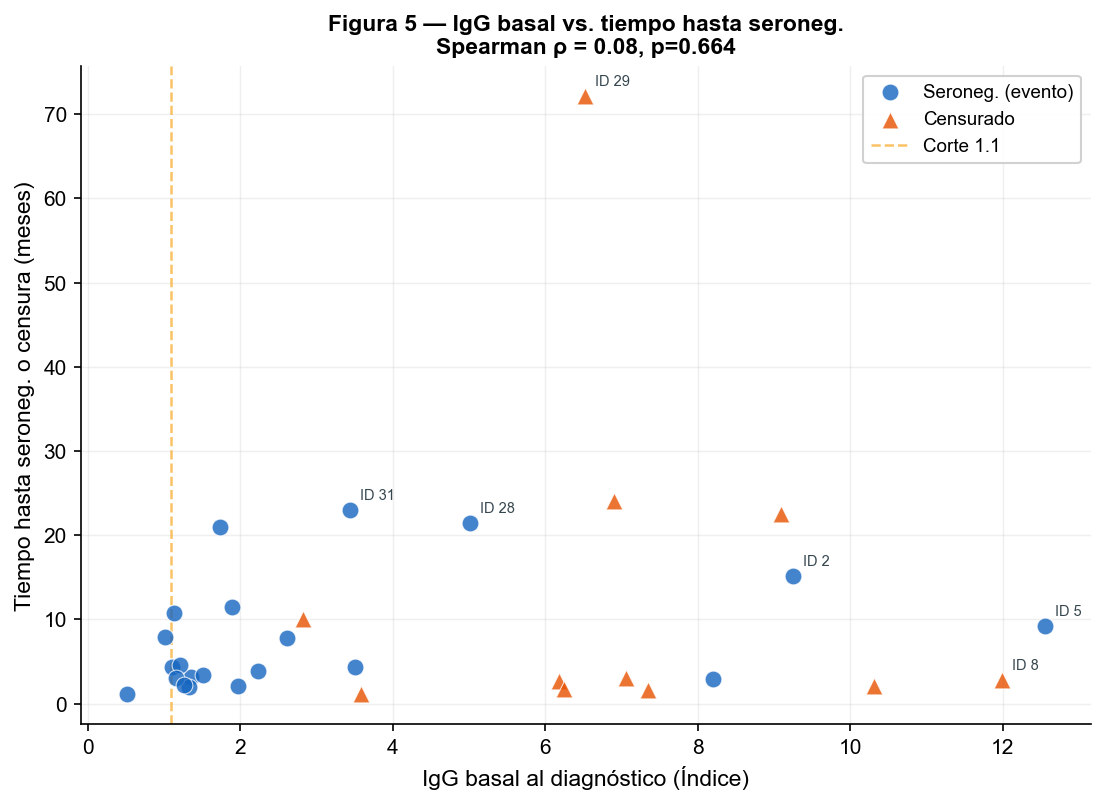

💾 Guardada en outputs/figures/fig05_scatter_igg_tiempo.png


In [13]:
# ── 03-E | Figura 5: IgG basal vs. tiempo hasta seroneg (scatter) ────────
#
# CONCEPTO:
#   Scatter plot con Spearman ρ.
#   - Cada punto = un paciente.
#   - Eje X = IgG basal (cuánto anticuerpo tenía al inicio).
#   - Eje Y = tiempo hasta seroneg. o censura (meses).
#   - Forma y color distinguen evento vs. censura.
#
#   Spearman ρ mide correlación de RANGOS (no paramétrico).
#   No asume linealidad ni normalidad → robusto frente a outliers.
#   Rango: -1 (inversamente correlacionados) a +1 (directamente).
#
# ANATOMÍA:
#   ax.scatter(x, y, c=color, marker='o', ...)
#     c = color del punto.
#     marker = forma ('o'=círculo, '^'=triángulo, 's'=cuadrado).
#     s = tamaño, alpha = transparencia.
#     edgecolors='white', linewidths=0.5 → borde blanco para separar puntos.
#
#   scipy_stats.spearmanr(x, y) → (ρ, p-valor)

fig, ax = plt.subplots(figsize=(7.5, 5.5))

for ev, c, lbl, mk in [
    (1, PAL['seroneg'],    'Seroneg. (evento)', 'o'),
    (0, PAL['no_seroneg'], 'Censurado',         '^'),
]:
    sub = df[
        (df['EVENT_SERONEG'] == ev) &
        df['IGG_BASAL'].notna() &
        df['TIME_TO_SERONEG_M'].notna()
    ]
    ax.scatter(
        sub['IGG_BASAL'], sub['TIME_TO_SERONEG_M'],
        c=c, marker=mk, s=65, alpha=0.8, label=lbl,
        zorder=4, edgecolors='white', linewidths=0.5,
    )

    # Etiquetar outliers (P90 en X o Y)
    thresh_igg = sub['IGG_BASAL'].quantile(0.9)
    thresh_t   = sub['TIME_TO_SERONEG_M'].quantile(0.9)
    outliers = sub[(sub['IGG_BASAL'] > thresh_igg) | (sub['TIME_TO_SERONEG_M'] > thresh_t)]
    for _, row in outliers.iterrows():
        ax.annotate(
            f"ID {int(row['ID'])}",
            (row['IGG_BASAL'], row['TIME_TO_SERONEG_M']),
            textcoords='offset points', xytext=(5, 5),
            fontsize=7, color=PAL['neutral'],
        )

# ── Spearman sobre todos los que tienen ambos valores ──
sub_all = df[df['IGG_BASAL'].notna() & df['TIME_TO_SERONEG_M'].notna()]
r, p = scipy_stats.spearmanr(sub_all['IGG_BASAL'], sub_all['TIME_TO_SERONEG_M'])

ax.axvline(1.1, color=PAL['highlight'], linestyle='--', linewidth=1.2,
           alpha=0.7, label='Corte 1.1')
ax.set_xlabel('IgG basal al diagnóstico (Índice)', fontsize=11)
ax.set_ylabel('Tiempo hasta seroneg. o censura (meses)', fontsize=11)
p_str = f'p={p:.3f}' if p >= 0.001 else 'p<0.001'
ax.set_title(
    f'Figura 5 — IgG basal vs. tiempo hasta seroneg.\n'
    f'Spearman ρ = {r:.2f}, {p_str}',
    fontsize=11, fontweight='bold',
)
ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig(OUT / 'figures' / 'fig05_scatter_igg_tiempo.png', dpi=300, bbox_inches='tight')
plt.show()
print('💾 Guardada en outputs/figures/fig05_scatter_igg_tiempo.png')

---
# BLOQUE 04 — Análisis de Supervivencia

### ¿Qué hacemos y por qué?

El **análisis de supervivencia** (o *time-to-event analysis*) es la herramienta estadística
central de este estudio. En lugar de preguntar "¿cuántos seronegatizaron?", preguntamos
"¿cuánto tiempo tardaron en seroconvertir, y qué factores lo aceleran o retrasan?"

Tres técnicas, una sobre otra:

| Técnica | Pregunta que responde | Output |
|---------|----------------------|--------|
| **Kaplan-Meier** | ¿Cuál es la probabilidad de seguir seropositivo a los 6, 12, 24 meses? | Curva de supervivencia |
| **Log-rank** | ¿Difieren las curvas de dos grupos (ej. inmunodeprimidos vs. no)? | p-valor |
| **Cox PH** | ¿Cuánto acelera/retrasa la seroneg. cada factor, ajustando por los demás? | Hazard Ratio (HR) |

> **Nota técnica:** las implementaciones de este bloque están hechas desde cero con
> `scipy` y `numpy`, sin depender de `lifelines` ni `statsmodels`. Esto hace el código
> más transparente y portable — y es ideal para una publicación metodológica.

In [14]:
# ── 04-A | Implementación de Kaplan-Meier desde cero ─────────────────────
#
# CONCEPTO:
#   Kaplan-Meier estima la probabilidad de "sobrevivir" (= seguir seropositivo)
#   más allá de cada tiempo t observado.
#
#   En cada tiempo donde ocurre un evento:
#     S(t) = S(t-1) × (1 - d_i / n_i)
#   donde:
#     d_i = número de eventos en t_i
#     n_i = número "a riesgo" justo antes de t_i (ni evento ni censura previa)
#
#   La CENSURA es clave: un paciente censurado a los 12 meses contribuye
#   al denominador hasta el mes 12, pero no después. No es un "fracaso"
#   ni un "éxito" — simplemente dejamos de observarlo.
#
# GREENWOOD (intervalos de confianza):
#   Var[S(t)] = S(t)² × Σ [d_i / (n_i × (n_i - d_i))]
#   IC 95% = S(t) ± 1.96 × √Var[S(t)]
#   (truncado a [0, 1] porque una probabilidad no puede salir de ese rango)
#
# ╔══════════════════════════════════════════════════════════════╗
# ║  Esta función devuelve todo lo necesario para dibujar        ║
# ║  curvas KM con IC y tabla de riesgo (numbers at risk).       ║
# ╚══════════════════════════════════════════════════════════════╝

def kaplan_meier(time, event):
    """
    Calcula el estimador de Kaplan-Meier con IC 95% (Greenwood).

    Parámetros
    ----------
    time  : array-like — tiempo hasta evento o censura (meses).
    event : array-like — 1 = evento (seroneg), 0 = censura.

    Retorna
    -------
    dict con claves:
        times    : tiempos únicos donde cambia S(t)
        survival : S(t) en cada tiempo
        ci_lower : límite inferior IC 95%
        ci_upper : límite superior IC 95%
        at_risk  : n a riesgo en cada tiempo
        events   : n eventos en cada tiempo
        median   : mediana de supervivencia (None si no se alcanza)
    """
    # Eliminar NaN
    mask = np.isfinite(time) & np.isfinite(event)
    time = np.array(time)[mask]
    event = np.array(event)[mask]
    n_total = len(time)

    # Ordenar por tiempo
    order = np.argsort(time)
    time = time[order]
    event = event[order]

    # Tiempos únicos donde OCURRE algo (evento o censura)
    unique_times = np.unique(time)

    km_times = [0.0]      # Empezamos en t=0
    km_surv  = [1.0]      # S(0) = 1.0 (todos vivos al inicio)
    km_risk  = [n_total]
    km_events = [0]

    n_at_risk = n_total
    surv = 1.0
    greenwood_sum = 0.0

    ci_lo = [1.0]
    ci_hi = [1.0]

    for t in unique_times:
        # d_i = eventos en tiempo t
        d_i = np.sum((time == t) & (event == 1))
        # c_i = censuras en tiempo t
        c_i = np.sum((time == t) & (event == 0))

        if d_i > 0:
            # Actualizar supervivencia
            surv *= (1 - d_i / n_at_risk)
            # Greenwood
            if n_at_risk > d_i:
                greenwood_sum += d_i / (n_at_risk * (n_at_risk - d_i))
            # IC 95%
            se = surv * np.sqrt(greenwood_sum)
            lo = max(0, surv - 1.96 * se)
            hi = min(1, surv + 1.96 * se)
        else:
            lo = ci_lo[-1]
            hi = ci_hi[-1]

        km_times.append(t)
        km_surv.append(surv)
        km_risk.append(n_at_risk)
        km_events.append(d_i)
        ci_lo.append(lo)
        ci_hi.append(hi)

        # Actualizar n a riesgo (se van eventos + censuras)
        n_at_risk -= (d_i + c_i)

    # Mediana: primer tiempo donde S(t) ≤ 0.5
    median = None
    for t, s in zip(km_times, km_surv):
        if s <= 0.5:
            median = t
            break

    return {
        'times': np.array(km_times),
        'survival': np.array(km_surv),
        'ci_lower': np.array(ci_lo),
        'ci_upper': np.array(ci_hi),
        'at_risk': np.array(km_risk),
        'events': np.array(km_events),
        'median': median,
        'n_total': len(time),
        'n_events': int(event.sum()),
    }

print('✅ Función kaplan_meier() definida')
print('   Implementa KM con IC 95% (Greenwood) desde cero.')

✅ Función kaplan_meier() definida
   Implementa KM con IC 95% (Greenwood) desde cero.


In [15]:
# ── 04-B | Test log-rank desde cero ──────────────────────────────────────
#
# CONCEPTO:
#   El log-rank test compara DOS curvas de Kaplan-Meier.
#   H₀: las curvas de supervivencia son iguales (misma distribución de tiempo).
#
#   En cada tiempo t_i donde ocurre al menos un evento:
#     - Observamos cuántos eventos hay en el grupo 1 (O₁ᵢ)
#     - Calculamos cuántos ESPERARÍAMOS si ambos grupos fueran iguales (E₁ᵢ)
#     - E₁ᵢ = n₁ᵢ × d_i / n_i   (proporcional al tamaño del grupo)
#
#   Estadístico: χ² = (Σ O₁ᵢ - Σ E₁ᵢ)² / Σ V_i
#   donde V_i es la varianza hipergeométrica en cada tiempo.
#   Bajo H₀, sigue una distribución chi² con 1 grado de libertad.

def logrank_test(time1, event1, time2, event2):
    """
    Test log-rank (Mantel-Cox) entre dos grupos.

    Retorna
    -------
    dict con: statistic, p_value, O1, E1, O2, E2
    """
    # Combinar datos
    t_all = np.concatenate([time1, time2])
    e_all = np.concatenate([event1, event2])
    g_all = np.concatenate([np.ones(len(time1)), np.zeros(len(time2))])

    # Solo tiempos con eventos
    event_times = np.unique(t_all[e_all == 1])
    event_times.sort()

    O1 = 0  # Total observado grupo 1
    E1 = 0  # Total esperado grupo 1
    V  = 0  # Varianza total

    for t in event_times:
        # Quién está a riesgo en t (no ha tenido evento ni censura ANTES de t)
        at_risk = t_all >= t
        n  = at_risk.sum()                          # Total a riesgo
        n1 = (at_risk & (g_all == 1)).sum()         # Grupo 1 a riesgo
        d  = ((t_all == t) & (e_all == 1)).sum()    # Eventos en t
        d1 = ((t_all == t) & (e_all == 1) & (g_all == 1)).sum()

        if n < 2:
            continue

        e1 = n1 * d / n                             # Esperado grupo 1
        # Varianza hipergeométrica
        n2 = n - n1
        v = (n1 * n2 * d * (n - d)) / (n**2 * (n - 1)) if n > 1 else 0

        O1 += d1
        E1 += e1
        V  += v

    O2 = (e_all[g_all == 0] == 1).sum()
    E2 = O2 + O1 - E1  # E2 = Total eventos - E1

    # Estadístico chi²
    chi2 = (O1 - E1)**2 / V if V > 0 else 0
    p = 1 - scipy_stats.chi2.cdf(chi2, df=1)

    return {
        'statistic': chi2,
        'p_value': p,
        'O1': O1, 'E1': round(E1, 2),
        'O2': int(O2), 'E2': round(E2, 2),
    }

print('✅ Función logrank_test() definida')
print('   Implementa Mantel-Cox log-rank desde cero.')

✅ Función logrank_test() definida
   Implementa Mantel-Cox log-rank desde cero.


In [16]:
# ── 04-C | Regresión de Cox (proporcional hazards) desde cero ─────────────
#
# CONCEPTO:
#   El modelo de Cox estima el efecto de covariables sobre la "tasa de riesgo"
#   (hazard) sin asumir una distribución concreta del tiempo.
#
#   h(t|X) = h₀(t) × exp(β₁X₁ + β₂X₂ + ...)
#
#   h₀(t) = hazard basal (no lo estimamos directamente).
#   exp(βᵢ) = HAZARD RATIO (HR) de la variable Xᵢ:
#     HR > 1 → factor de RIESGO (acelera el evento)
#     HR < 1 → factor PROTECTOR (retrasa el evento)
#     HR = 1 → sin efecto
#
# IMPLEMENTACIÓN:
#   Maximizamos la log-verosimilitud parcial de Cox:
#     ℓ(β) = Σᵢ [βᵀXᵢ - log(Σⱼ∈R(tᵢ) exp(βᵀXⱼ))]
#   donde R(tᵢ) es el "risk set" (pacientes a riesgo) en el tiempo tᵢ.
#
#   Usamos scipy.optimize.minimize (método BFGS) para encontrar los β óptimos.
#   Los errores estándar vienen de la inversa de la matriz de información (Hessiana).

from scipy.optimize import minimize

def cox_ph(time, event, X, var_names=None):
    """
    Regresión de Cox univariable o multivariable.

    Parámetros
    ----------
    time      : array (n,) — tiempo hasta evento/censura.
    event     : array (n,) — 1=evento, 0=censura.
    X         : array (n, p) — matriz de covariables.
    var_names : list de str — nombres de las variables.

    Retorna
    -------
    DataFrame con: variable, coef (β), HR, IC95_lo, IC95_hi, se, z, p.
    """
    time = np.asarray(time, dtype=float)
    event = np.asarray(event, dtype=float)
    X = np.asarray(X, dtype=float)
    if X.ndim == 1:
        X = X.reshape(-1, 1)
    n, p = X.shape

    if var_names is None:
        var_names = [f'X{i+1}' for i in range(p)]

    # Eliminar filas con NaN
    mask = np.isfinite(time) & np.isfinite(event) & np.all(np.isfinite(X), axis=1)
    time, event, X = time[mask], event[mask], X[mask]

    # Ordenar por tiempo (descendente para eficiencia en risk sets)
    order = np.argsort(-time)
    time, event, X = time[order], event[order], X[order]

    def neg_log_partial_likelihood(beta):
        """Log-verosimilitud parcial negativa (a minimizar)."""
        Xb = X @ beta                       # (n,) — riesgo lineal de cada paciente
        # Cumulative sum en orden inverso (= risk set sum)
        # Como está ordenado de mayor a menor tiempo,
        # la cumsum da el denominador del risk set.
        exp_Xb = np.exp(Xb - Xb.max())      # Estabilización numérica
        risk_sum = np.cumsum(exp_Xb)          # Σ exp(βX) sobre el risk set
        risk_sum = np.maximum(risk_sum, 1e-20)

        log_lik = np.sum(event * (Xb - np.log(risk_sum) - Xb.max() + np.log(np.exp(Xb.max()))))
        # Simplificado:
        log_lik = np.sum(event * (Xb - np.log(risk_sum * np.exp(Xb.max()))))

        return -log_lik

    def neg_log_pl_clean(beta):
        """Versión limpia y numéricamente estable."""
        Xb = X @ beta
        max_Xb = np.max(Xb)
        exp_Xb = np.exp(Xb - max_Xb)
        cum_exp = np.cumsum(exp_Xb)
        cum_exp = np.maximum(cum_exp, 1e-30)

        ll = np.sum(event * (Xb - max_Xb - np.log(cum_exp)))
        return -ll

    # Optimización
    beta0 = np.zeros(p)
    result = minimize(neg_log_pl_clean, beta0, method='BFGS')
    beta_hat = result.x

    # Hessiana numérica → errores estándar
    # Usamos diferencias finitas
    eps = 1e-5
    hess = np.zeros((p, p))
    f0 = neg_log_pl_clean(beta_hat)
    for i in range(p):
        for j in range(i, p):
            e_i = np.zeros(p); e_i[i] = eps
            e_j = np.zeros(p); e_j[j] = eps
            f_pp = neg_log_pl_clean(beta_hat + e_i + e_j)
            f_pm = neg_log_pl_clean(beta_hat + e_i - e_j)
            f_mp = neg_log_pl_clean(beta_hat - e_i + e_j)
            f_mm = neg_log_pl_clean(beta_hat - e_i - e_j)
            hess[i, j] = (f_pp - f_pm - f_mp + f_mm) / (4 * eps**2)
            hess[j, i] = hess[i, j]

    # Inversa de la Hessiana → varianza de los coeficientes
    try:
        cov = np.linalg.inv(hess)
        se = np.sqrt(np.maximum(np.diag(cov), 1e-20))
    except np.linalg.LinAlgError:
        se = np.full(p, np.nan)

    z = beta_hat / se
    p_val = 2 * (1 - scipy_stats.norm.cdf(np.abs(z)))
    hr = np.exp(beta_hat)
    hr_lo = np.exp(beta_hat - 1.96 * se)
    hr_hi = np.exp(beta_hat + 1.96 * se)

    results = pd.DataFrame({
        'Variable': var_names,
        'coef': np.round(beta_hat, 4),
        'HR': np.round(hr, 3),
        'IC95_lo': np.round(hr_lo, 3),
        'IC95_hi': np.round(hr_hi, 3),
        'se': np.round(se, 4),
        'z': np.round(z, 3),
        'p': p_val,
        'n': [int(mask.sum())] * p,
        'events': [int(event.sum())] * p,
    })

    return results

print('✅ Función cox_ph() definida')
print('   Implementa Cox PH con BFGS + Hessiana numérica.')

✅ Función cox_ph() definida
   Implementa Cox PH con BFGS + Hessiana numérica.


#### 🔬 Anatomía de las funciones de supervivencia

**Kaplan-Meier — ¿por qué funciona con censura?**
La clave es el denominador `n_i` (número a riesgo). Cuando un paciente se censura en `t=12`, sale del denominador a partir de ese punto — ya no contribuye ni como evento ni como no-evento. Así la estimación de `S(t)` no se sesga por el hecho de que algunos pacientes se pierden antes.

**Log-rank — intuición**
En cada tiempo de evento, preguntamos: "si ambos grupos tuvieran la misma distribución, ¿cuántos eventos esperaríamos en el grupo 1?". Si la suma de observados difiere significativamente de la suma de esperados → los grupos tienen curvas diferentes.

**Cox PH — ¿qué es la verosimilitud parcial?**
En lugar de modelar `h₀(t)` (el riesgo basal en el tiempo), Cox se deshace de él usando un truco: en cada tiempo de evento, mira las probabilidades *relativas* de que el evento le ocurra a cada paciente del risk set. Así solo estima los `β` (efectos de las covariables), sin asumir ninguna forma concreta para `h₀(t)`. Por eso se llama "semi-paramétrico".

**Hazard Ratio (HR) — interpretación clínica**
- HR = 2.0 para una variable → los pacientes con esa característica seronegativan "al doble de velocidad".
- HR = 0.5 → seronegativan "a la mitad de velocidad" (= tardan más).
- IC 95% que incluye 1.0 → efecto no significativo.

Pacientes para KM: 40 (excluidos 4 sin tiempo)


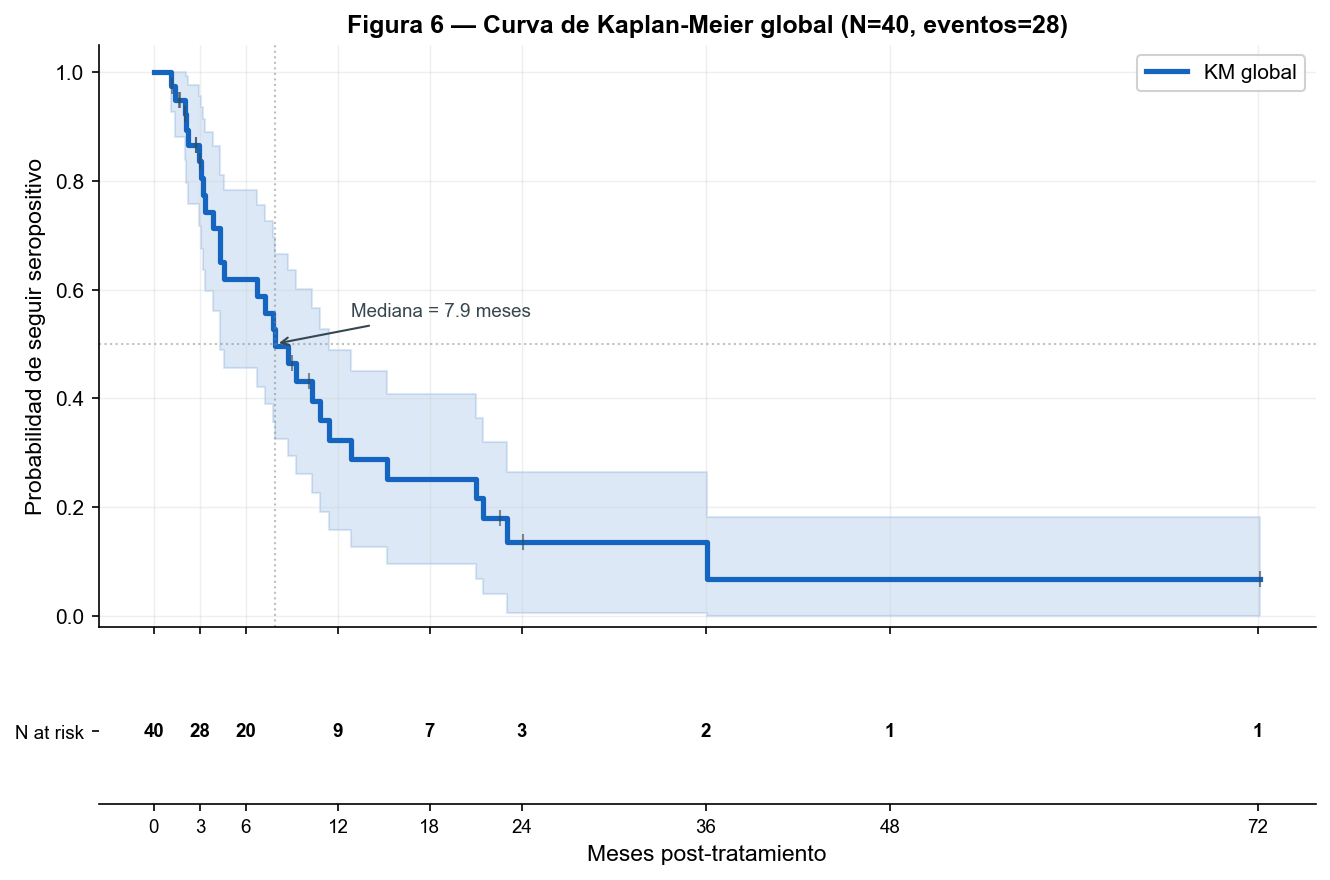

💾 Guardada. Mediana de seroneg.: 7.9 meses


In [17]:
# ── 04-D | Figura 6: Curva KM global + tabla de riesgo ───────────────────
#
# CONCEPTO:
#   La curva KM global (sin estratificar) responde a:
#   "¿Cuál es la probabilidad de seguir seropositivo a los 6, 12, 24 meses
#    en el conjunto de la cohorte?"
#
#   Debajo de la curva ponemos una TABLA DE RIESGO (numbers at risk):
#   cuántos pacientes siguen siendo observables en cada timepoint.
#   Es obligatoria en publicaciones (Consort / STROBE guidelines).
#
# ANATOMÍA:
#   fig, (ax_km, ax_table) = plt.subplots(2, 1, ...)
#     gridspec_kw={'height_ratios': [4, 1]} → el gráfico ocupa 4/5, la tabla 1/5.
#     sharex=True → ambos comparten el eje X.
#
#   ax.fill_between(x, y_lo, y_hi, alpha=0.15) → banda de IC 95%.
#   ax.step(x, y, where='post') → escalón (KM es función escalonada, no suave).

# Filtrar pacientes con tiempo disponible
km_data = df[df['TIME_TO_SERONEG_M'].notna()].copy()
print(f"Pacientes para KM: {len(km_data)} (excluidos {44 - len(km_data)} sin tiempo)")

# KM global
km_global = kaplan_meier(
    km_data['TIME_TO_SERONEG_M'].values,
    km_data['EVENT_SERONEG'].values,
)

# Timepoints para la tabla de riesgo
RISK_TIMEPOINTS = [0, 3, 6, 12, 18, 24, 36, 48, 72]

def numbers_at_risk(time, event, timepoints):
    """Calcula n a riesgo en cada timepoint (para la tabla debajo del KM)."""
    time = np.array(time)
    return [int(np.sum(time >= t)) for t in timepoints]

nar_global = numbers_at_risk(
    km_data['TIME_TO_SERONEG_M'].values,
    km_data['EVENT_SERONEG'].values,
    RISK_TIMEPOINTS,
)

# ── Dibujar ──
fig, (ax_km, ax_table) = plt.subplots(
    2, 1, figsize=(9, 6),
    gridspec_kw={'height_ratios': [4, 1]},
    sharex=True,
)

# Curva KM (escalón)
ax_km.step(km_global['times'], km_global['survival'],
           where='post', color=PAL['seroneg'], linewidth=2.5, label='KM global')

# IC 95% (banda sombreada)
ax_km.fill_between(
    km_global['times'], km_global['ci_lower'], km_global['ci_upper'],
    step='post', alpha=0.15, color=PAL['seroneg'],
)

# Mediana
if km_global['median'] is not None:
    med = km_global['median']
    ax_km.axhline(0.5, color='grey', linestyle=':', linewidth=1, alpha=0.5)
    ax_km.axvline(med, color='grey', linestyle=':', linewidth=1, alpha=0.5)
    ax_km.annotate(
        f'Mediana = {med:.1f} meses',
        xy=(med, 0.5), xytext=(med + 5, 0.55),
        fontsize=9, color=PAL['neutral'],
        arrowprops=dict(arrowstyle='->', color=PAL['neutral'], lw=1),
    )

# Marcas de censura (tickmarks)
cens_times = km_data[km_data['EVENT_SERONEG'] == 0]['TIME_TO_SERONEG_M'].values
for ct in cens_times:
    idx = np.searchsorted(km_global['times'], ct, side='right') - 1
    s_at_cens = km_global['survival'][max(0, idx)]
    ax_km.plot(ct, s_at_cens, '|', color=PAL['neutral'], markersize=8, alpha=0.6)

ax_km.set_ylabel('Probabilidad de seguir seropositivo', fontsize=11)
ax_km.set_ylim(-0.02, 1.05)
ax_km.set_title(
    f'Figura 6 — Curva de Kaplan-Meier global (N={len(km_data)}, eventos={km_global["n_events"]})',
    fontsize=12, fontweight='bold',
)
ax_km.legend(fontsize=10, loc='upper right')

# ── Tabla de riesgo ──
ax_table.set_xlim(ax_km.get_xlim())
for i, (t, n) in enumerate(zip(RISK_TIMEPOINTS, nar_global)):
    ax_table.text(t, 0.5, str(n), ha='center', va='center', fontsize=9,
                  fontweight='bold' if n > 0 else 'normal')
ax_table.set_yticks([0.5])
ax_table.set_yticklabels(['N at risk'], fontsize=9)
ax_table.set_xlabel('Meses post-tratamiento', fontsize=11)
ax_table.set_xticks(RISK_TIMEPOINTS)
ax_table.tick_params(axis='x', labelsize=9)
ax_table.spines['left'].set_visible(False)
ax_table.spines['bottom'].set_visible(True)
ax_table.grid(False)

plt.tight_layout()
plt.savefig(OUT / 'figures' / 'fig06_km_global.png', dpi=300, bbox_inches='tight')
plt.show()
print(f'💾 Guardada. Mediana de seroneg.: {km_global["median"]:.1f} meses' if km_global['median'] else '💾 Guardada. Mediana no alcanzada.')

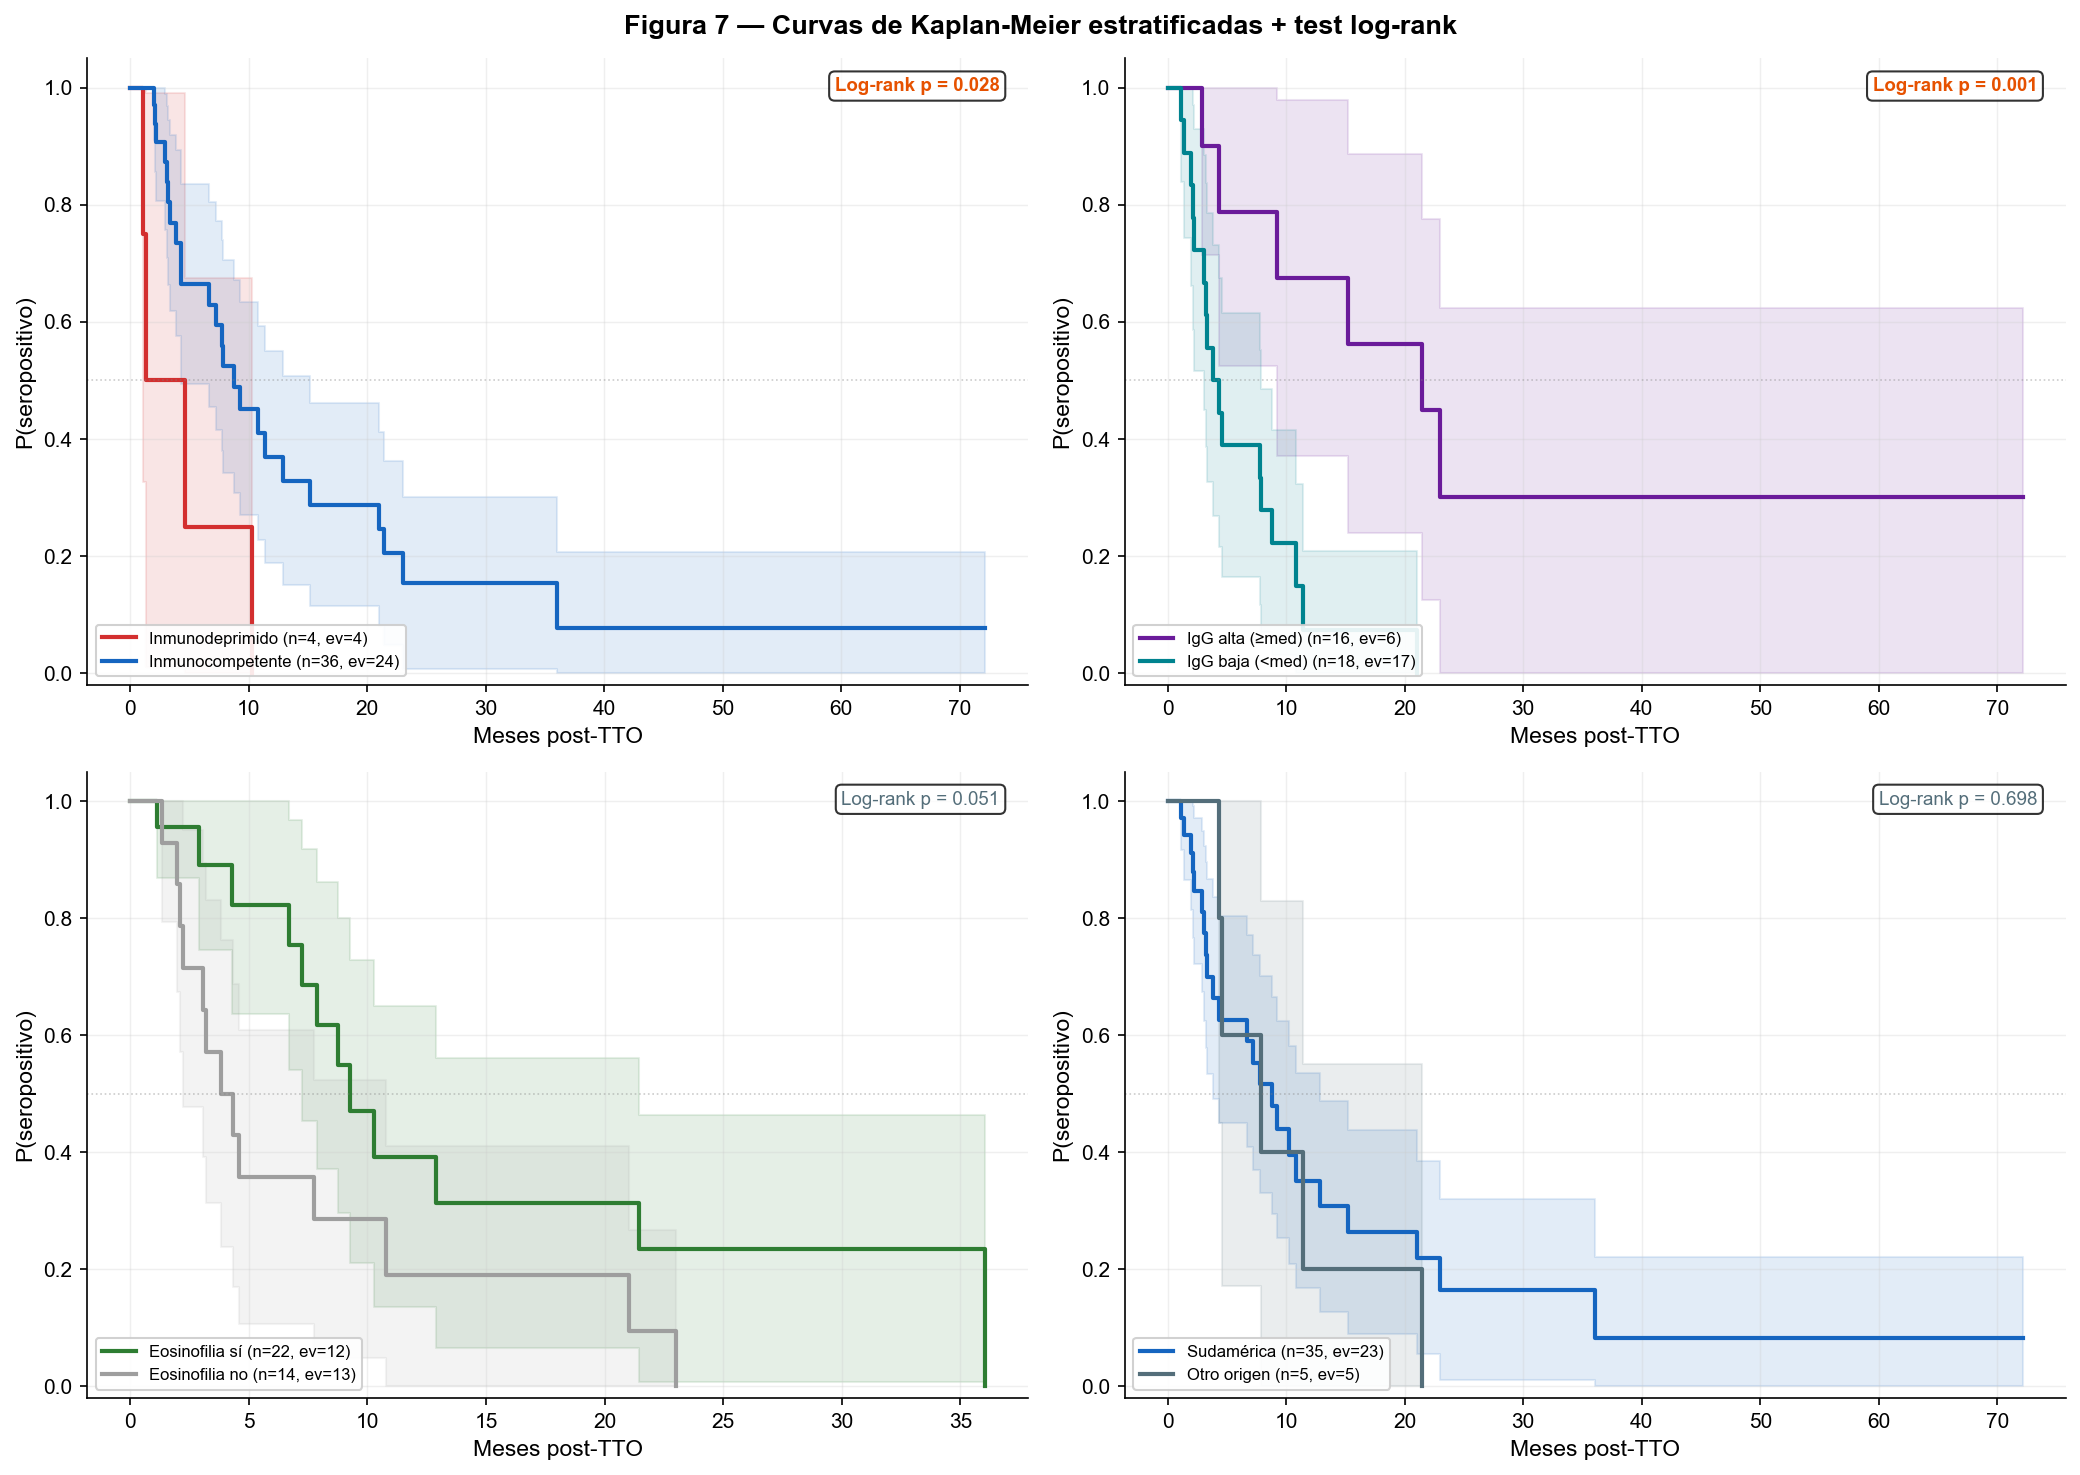

💾 Guardada en outputs/figures/fig07_km_estratificado.png


In [18]:
# ── 04-E | Figura 7: KM estratificado por factores clínicos + log-rank ────
#
# CONCEPTO:
#   Repetimos la curva KM pero dividiendo la cohorte por diferentes factores.
#   El test log-rank nos dice si las curvas son significativamente diferentes.
#
#   Cada panel = una variable de estratificación.
#   Dentro de cada panel = dos curvas (una por grupo).
#
# ╔══════════════════════════════════════════════════════════════╗
# ║  ESTRATIFICACIONES: modifica esta lista para añadir/quitar   ║
# ║  factores. Formato: (columna, valor_grupo1, label1, color1,  ║
# ║                       valor_grupo2, label2, color2)          ║
# ╚══════════════════════════════════════════════════════════════╝

STRAT_VARS = [
    ('INMUNO_DICO',      1, 'Inmunodeprimido',  PAL['inmuno_dep'],
                         2, 'Inmunocompetente', PAL['inmuno_comp']),
    ('IGG_BASAL_ALTA',   1, 'IgG alta (≥med)',  PAL['igg_alta'],
                         2, 'IgG baja (<med)',   PAL['igg_baja']),
    ('EOS_BASAL_BIN',    1, 'Eosinofilia sí',   PAL['eos_si'],
                         2, 'Eosinofilia no',    PAL['eos_no']),
    ('ORIGEN_DICO2',     1, 'Sudamérica',        PAL['sudamerica'],
                         2, 'Otro origen',       PAL['otro_origen']),
]

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes_flat = axes.flatten()

for ax, (col, v1, lb1, c1, v2, lb2, c2) in zip(axes_flat, STRAT_VARS):
    # Filtrar datos válidos
    sub = km_data[km_data[col].notna()].copy()

    g1 = sub[sub[col] == v1]
    g2 = sub[sub[col] == v2]

    if len(g1) < 2 or len(g2) < 2:
        ax.text(0.5, 0.5, f'{col}: grupos demasiado\npequeños para KM',
                ha='center', va='center', transform=ax.transAxes)
        continue

    km1 = kaplan_meier(g1['TIME_TO_SERONEG_M'].values, g1['EVENT_SERONEG'].values)
    km2 = kaplan_meier(g2['TIME_TO_SERONEG_M'].values, g2['EVENT_SERONEG'].values)

    # Log-rank
    lr = logrank_test(
        g1['TIME_TO_SERONEG_M'].values, g1['EVENT_SERONEG'].values,
        g2['TIME_TO_SERONEG_M'].values, g2['EVENT_SERONEG'].values,
    )

    # Curvas
    ax.step(km1['times'], km1['survival'], where='post', color=c1, linewidth=2,
            label=f'{lb1} (n={len(g1)}, ev={km1["n_events"]})')
    ax.fill_between(km1['times'], km1['ci_lower'], km1['ci_upper'],
                    step='post', alpha=0.12, color=c1)

    ax.step(km2['times'], km2['survival'], where='post', color=c2, linewidth=2,
            label=f'{lb2} (n={len(g2)}, ev={km2["n_events"]})')
    ax.fill_between(km2['times'], km2['ci_lower'], km2['ci_upper'],
                    step='post', alpha=0.12, color=c2)

    # p-valor log-rank
    p = lr['p_value']
    p_str = f'p = {p:.3f}' if p >= 0.001 else 'p < 0.001'
    color_p = '#E65100' if p < 0.05 else '#546E7A'
    ax.text(0.97, 0.97, f'Log-rank {p_str}', transform=ax.transAxes,
            ha='right', va='top', fontsize=9, color=color_p,
            fontweight='bold' if p < 0.05 else 'normal',
            bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.8))

    ax.set_ylim(-0.02, 1.05)
    ax.set_ylabel('P(seropositivo)')
    ax.set_xlabel('Meses post-TTO')
    ax.legend(fontsize=8, loc='lower left')
    ax.axhline(0.5, color='grey', linestyle=':', linewidth=0.8, alpha=0.4)

fig.suptitle('Figura 7 — Curvas de Kaplan-Meier estratificadas + test log-rank',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(OUT / 'figures' / 'fig07_km_estratificado.png', dpi=300, bbox_inches='tight')
plt.show()
print('💾 Guardada en outputs/figures/fig07_km_estratificado.png')

In [19]:
# ── 04-F | Cox univariable: HR de cada factor por separado ────────────────
#
# CONCEPTO:
#   Antes de ajustar un modelo multivariable, evaluamos cada factor SOLO.
#   Esto responde: "¿tiene este factor, por sí mismo, efecto sobre la
#   velocidad de seronegativización?"
#
#   Criterio habitual para pasar al multivariable:
#   - p < 0.20 en univariable (más liberal que 0.05, para no perder confusores)
#   - O relevancia clínica independientemente del p-valor
#
# ╔══════════════════════════════════════════════════════════════╗
# ║  COVARIABLES: modifica esta lista para añadir/quitar         ║
# ║  factores del análisis univariable.                          ║
# ╚══════════════════════════════════════════════════════════════╝

COX_UNIVAR = [
    ('EDAD_DX',          'Edad (años)',           'continua'),
    ('SEXO_COD',         'Sexo (1=M, 2=V)',       'binaria'),
    ('INMUNO_DICO',      'Inmunodeprimido (1=sí)', 'binaria'),
    ('IGG_BASAL',        'IgG basal (índice)',     'continua'),
    ('IGG_BASAL_ALTA',   'IgG alta ≥mediana (1)',  'binaria'),
    ('EOS_BASAL',        'Eosinófilos (10³/µL)',   'continua'),
    ('EOS_BASAL_BIN',    'Eosinofilia >500 (1=sí)','binaria'),
    ('ORIGEN_DICO2',     'Sudamérica (1=sí)',      'binaria'),
    ('T_RESIDENCIA',     'Años residencia España', 'continua'),
    ('COMORB_INMUNO',    'Comorb. inmuno (0/1/2)', 'continua'),
]

all_results = []

for col, label, tipo in COX_UNIVAR:
    sub = km_data[[col, 'TIME_TO_SERONEG_M', 'EVENT_SERONEG']].dropna()
    if len(sub) < 10:
        print(f'  ⚠️ {label}: solo {len(sub)} obs → omitido')
        continue

    res = cox_ph(
        sub['TIME_TO_SERONEG_M'].values,
        sub['EVENT_SERONEG'].values,
        sub[[col]].values,
        var_names=[label],
    )
    all_results.append(res)

cox_uni = pd.concat(all_results, ignore_index=True)

# Formatear p-valor
cox_uni['p_fmt'] = cox_uni['p'].apply(lambda x: '<0.001' if x < 0.001 else f'{x:.3f}')

# Significancia
cox_uni['sig'] = cox_uni['p'].apply(lambda x: '***' if x<0.001 else ('**' if x<0.01 else ('*' if x<0.05 else ('†' if x<0.20 else ''))))

print('\n' + '='*85)
print('REGRESIÓN DE COX — ANÁLISIS UNIVARIABLE')
print('='*85)
display(cox_uni[['Variable', 'n', 'events', 'HR', 'IC95_lo', 'IC95_hi', 'p_fmt', 'sig']])
print('\n* p<0.05  ** p<0.01  *** p<0.001  † p<0.20 (candidato a multivariable)')

# Guardar
cox_uni.to_csv(OUT / 'tables' / 'cox_univariable.csv', index=False, encoding='utf-8-sig')
print('💾 Guardada en outputs/tables/cox_univariable.csv')


REGRESIÓN DE COX — ANÁLISIS UNIVARIABLE


,Variable,n,events,HR,IC95_lo,IC95_hi,p_fmt,sig
0,Edad (años),40,28,0.973,0.941,1.005,0.097,†
1,"Sexo (1=M, 2=V)",40,28,2.993,1.290,6.946,0.011,*
2,Inmunodeprimido (1=sí),40,28,0.311,0.103,0.933,0.037,*
3,IgG basal (índice),32,21,0.783,0.640,0.958,0.017,*
4,IgG alta ≥mediana (1),34,23,5.563,1.780,17.390,0.003,**
5,Eosinófilos (10³/µL),38,26,0.786,0.445,1.389,0.407,
6,Eosinofilia >500 (1=sí),36,25,2.195,0.977,4.929,0.057,†
7,Sudamérica (1=sí),40,28,1.214,0.456,3.229,0.698,
8,Años residencia España,37,27,1.009,0.955,1.066,0.750,
9,Comorb. inmuno (0/1/2),40,28,1.507,0.793,2.863,0.211,



* p<0.05  ** p<0.01  *** p<0.001  † p<0.20 (candidato a multivariable)
💾 Guardada en outputs/tables/cox_univariable.csv


In [20]:
# ── 04-G | Cox multivariable: modelo ajustado ─────────────────────────────
#
# CONCEPTO:
#   El modelo multivariable ajusta TODOS los factores simultáneamente.
#   Cada HR se interpreta como: "efecto de esta variable, manteniendo
#   constantes (ajustando por) todas las demás".
#
#   Esto es crucial porque una asociación univariable puede ser confundida
#   por un tercer factor. Ejemplo: si los inmunodeprimidos tienen IgG más alta,
#   la asociación IgG→tiempo puede estar confundida por el estado inmune.
#
# SELECCIÓN DE VARIABLES:
#   Incluimos las que tienen p < 0.20 en univariable O relevancia clínica.
#   Evitamos variables colineales (ej: no meter INMUNO_DICO + COMORB_INMUNO juntas).
#
# ╔══════════════════════════════════════════════════════════════╗
# ║  MODELO MULTIVARIABLE: modifica estas columnas para cambiar  ║
# ║  qué factores entran en el modelo ajustado.                  ║
# ╚══════════════════════════════════════════════════════════════╝

MULTI_VARS = [
    ('IGG_BASAL',    'IgG basal'),
    ('INMUNO_DICO',  'Inmunodeprimido'),
    ('EOS_BASAL',    'Eosinófilos basales'),
    ('EDAD_DX',      'Edad'),
]
multi_cols = [c for c, _ in MULTI_VARS]
multi_names = [n for _, n in MULTI_VARS]

# Dataset completo (sin NaN en ninguna de las variables)
sub_multi = km_data[multi_cols + ['TIME_TO_SERONEG_M', 'EVENT_SERONEG']].dropna()
print(f'N para modelo multivariable: {len(sub_multi)} (excluidos: {len(km_data) - len(sub_multi)} por NaN)')

cox_multi = cox_ph(
    sub_multi['TIME_TO_SERONEG_M'].values,
    sub_multi['EVENT_SERONEG'].values,
    sub_multi[multi_cols].values,
    var_names=multi_names,
)

cox_multi['p_fmt'] = cox_multi['p'].apply(lambda x: '<0.001' if x < 0.001 else f'{x:.3f}')
cox_multi['sig'] = cox_multi['p'].apply(lambda x: '***' if x<0.001 else ('**' if x<0.01 else ('*' if x<0.05 else '')))

print('\n' + '='*85)
print('REGRESIÓN DE COX — MODELO MULTIVARIABLE')
print('='*85)
display(cox_multi[['Variable', 'n', 'events', 'coef', 'HR', 'IC95_lo', 'IC95_hi', 'p_fmt', 'sig']])

cox_multi.to_csv(OUT / 'tables' / 'cox_multivariable.csv', index=False, encoding='utf-8-sig')
print('\n💾 Guardada en outputs/tables/cox_multivariable.csv')

N para modelo multivariable: 30 (excluidos: 10 por NaN)

REGRESIÓN DE COX — MODELO MULTIVARIABLE


,Variable,n,events,coef,HR,IC95_lo,IC95_hi,p_fmt,sig
0,IgG basal,30,19,-0.2659,0.766,0.591,0.994,0.045,*
1,Inmunodeprimido,30,19,-0.6126,0.542,0.108,2.711,0.456,
2,Eosinófilos basales,30,19,0.0084,1.008,0.622,1.635,0.973,
3,Edad,30,19,0.0002,1.000,0.954,1.048,0.994,



💾 Guardada en outputs/tables/cox_multivariable.csv


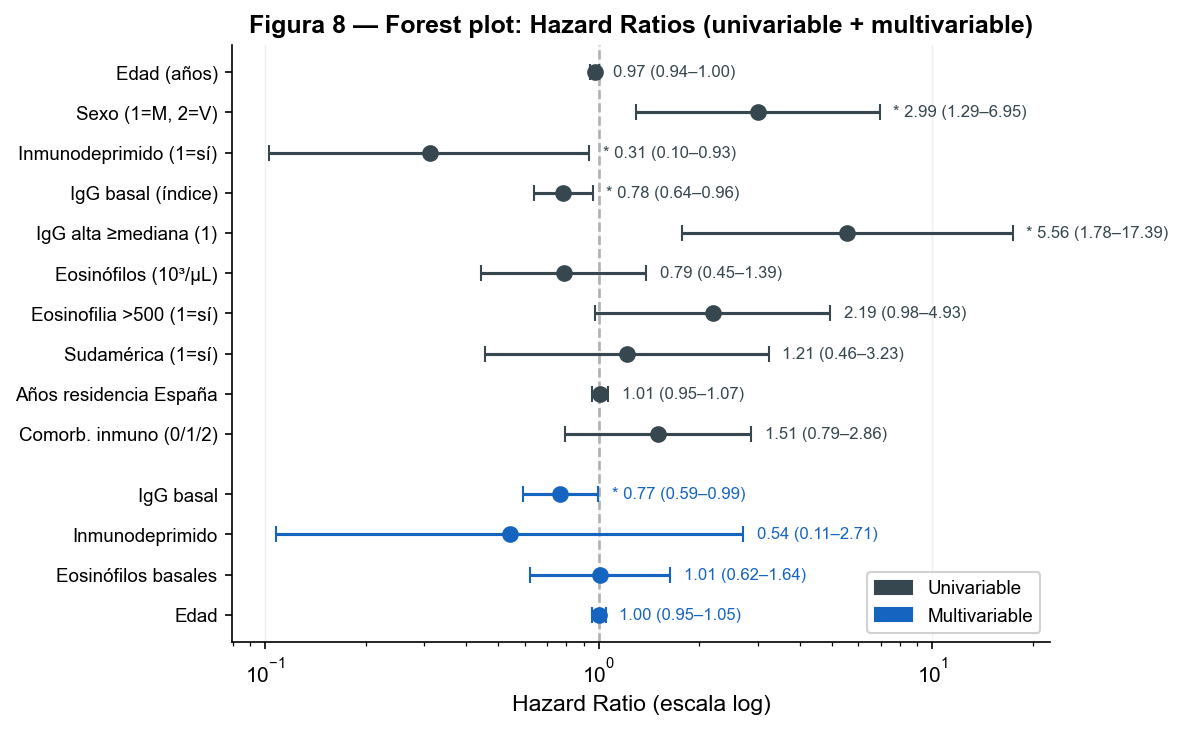

💾 Guardada en outputs/figures/fig08_forest_plot.png


In [21]:
# ── 04-H | Figura 8: Forest plot de Hazard Ratios ────────────────────────
#
# CONCEPTO:
#   El forest plot es la forma estándar de presentar los resultados de Cox.
#   Cada fila = una variable.
#   - Punto = HR estimado.
#   - Línea horizontal = IC 95%.
#   - Línea vertical en HR=1 = "sin efecto" (referencia).
#   - Si el IC cruza 1 → efecto NO significativo.
#
# ANATOMÍA:
#   ax.errorbar(x, y, xerr=[[lo], [hi]], ...) → punto con barras de error horizontales.
#     xerr recibe [[distancia_izquierda], [distancia_derecha]] desde el punto.
#
#   ax.axvline(1.0, ...) → línea vertical de referencia (HR = 1).
#
#   Escala logarítmica: HR se interpreta simétricamente en log.
#     HR=0.5 y HR=2.0 son "equidistantes" de 1.0 en escala log.

fig, ax = plt.subplots(figsize=(8, 5))

# Combinar univariable y multivariable
forest_data = [
    ('Univariable', cox_uni, PAL['neutral']),
    ('Multivariable', cox_multi, PAL['seroneg']),
]

y_pos = 0
y_labels = []
y_ticks = []

for model_label, data, color in forest_data:
    for _, row in data.iterrows():
        hr = row['HR']
        lo = row['IC95_lo']
        hi = row['IC95_hi']

        # Limitar para visualización (evitar líneas infinitas)
        lo_plot = max(lo, 0.05)
        hi_plot = min(hi, 20)

        ax.errorbar(
            hr, y_pos,
            xerr=[[hr - lo_plot], [hi_plot - hr]],
            fmt='o', color=color, markersize=7, capsize=4,
            linewidth=1.5, elinewidth=1.5,
        )

        # Texto con HR (IC95%)
        sig = '* ' if row['p'] < 0.05 else ''
        ax.text(
            hi_plot * 1.1, y_pos,
            f'{sig}{hr:.2f} ({lo:.2f}–{hi:.2f})',
            va='center', fontsize=8, color=color,
        )

        y_labels.append(f'{row["Variable"]}')
        y_ticks.append(y_pos)
        y_pos -= 1

    # Separador entre modelos
    y_pos -= 0.5

# Línea de referencia (HR = 1 = sin efecto)
ax.axvline(1.0, color='grey', linestyle='--', linewidth=1.2, alpha=0.7, zorder=0)

ax.set_xscale('log')
ax.set_xlabel('Hazard Ratio (escala log)', fontsize=11)
ax.set_yticks(y_ticks)
ax.set_yticklabels(y_labels, fontsize=9)
ax.set_title('Figura 8 — Forest plot: Hazard Ratios (univariable + multivariable)',
             fontsize=12, fontweight='bold')

# Leyenda manual
patches = [
    mpatches.Patch(color=PAL['neutral'], label='Univariable'),
    mpatches.Patch(color=PAL['seroneg'], label='Multivariable'),
]
ax.legend(handles=patches, fontsize=9, loc='lower right')

ax.grid(axis='x', alpha=0.3)
ax.grid(axis='y', visible=False)

plt.tight_layout()
plt.savefig(OUT / 'figures' / 'fig08_forest_plot.png', dpi=300, bbox_inches='tight')
plt.show()
print('💾 Guardada en outputs/figures/fig08_forest_plot.png')

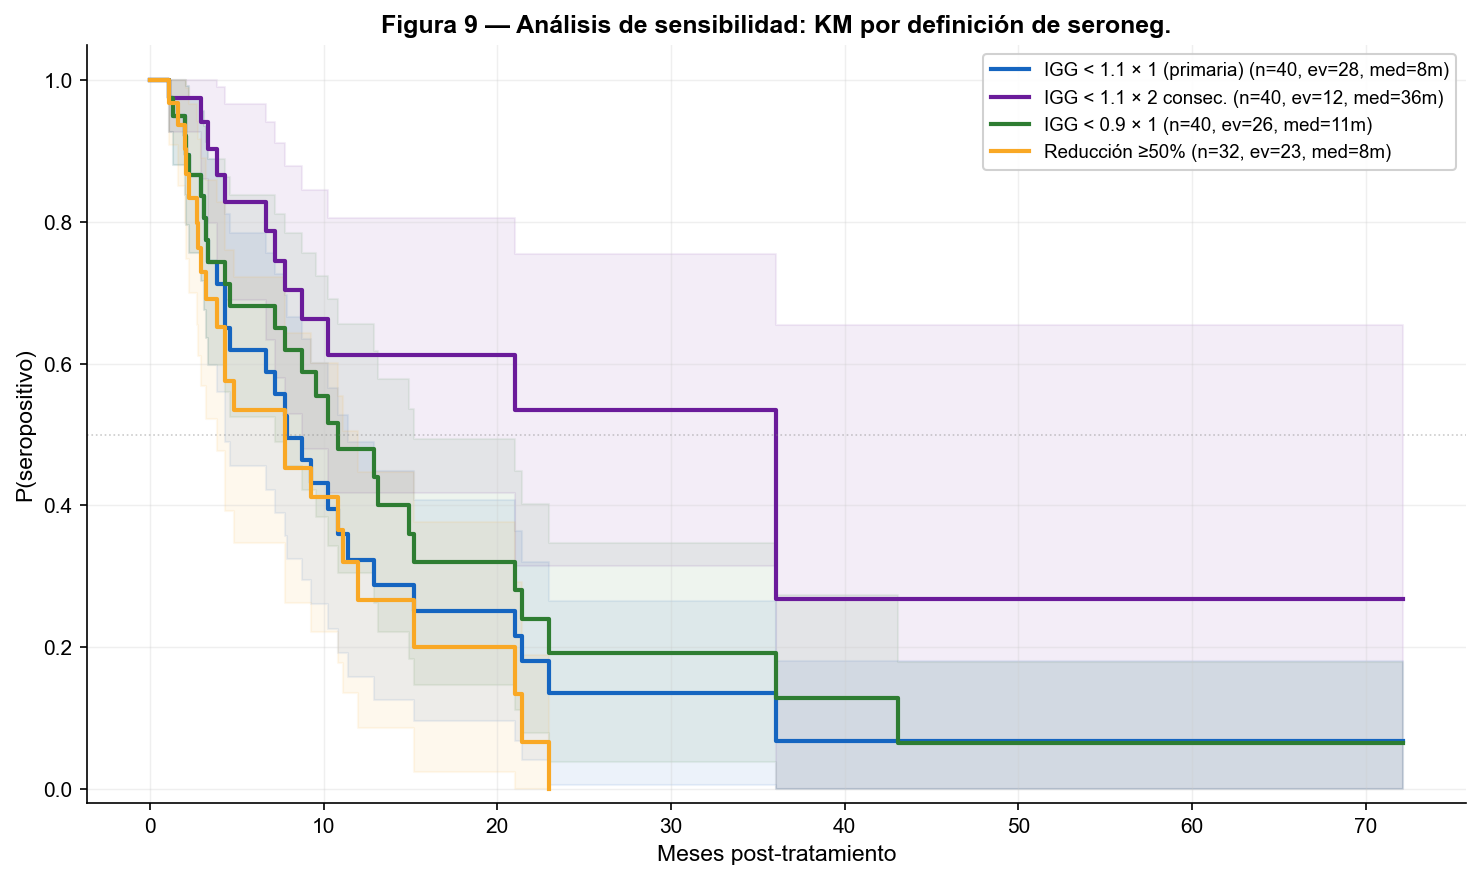

💾 Guardada en outputs/figures/fig09_km_sensibilidad.png


In [22]:
# ── 04-I | Análisis de sensibilidad: KM con definiciones alternativas ────
#
# CONCEPTO:
#   El análisis de sensibilidad comprueba si los resultados son robustos
#   cuando cambiamos la definición del outcome. Si las conclusiones se
#   mantienen con definiciones más o menos estrictas → los resultados
#   son más creíbles.
#
#   Comparamos 4 definiciones:
#   - Primaria: IGG < 1.1 × 1 medición
#   - IGG < 1.1 × 2 consecutivas
#   - IGG < 0.9 × 1 medición
#   - Reducción ≥50% × 1

SENS_DEFS = [
    ('EV_SERO_11_1X', 'T_SERO_11_1X', 'IGG < 1.1 × 1 (primaria)', PAL['seroneg']),
    ('EV_SERO_11_2X', 'T_SERO_11_2X', 'IGG < 1.1 × 2 consec.',    PAL['igg_alta']),
    ('EV_SERO_09_1X', 'T_SERO_09_1X', 'IGG < 0.9 × 1',            PAL['eos_si']),
    ('EV_50PCT_1X',   'T_50PCT_1X',   'Reducción ≥50%',            PAL['highlight']),
]

fig, ax = plt.subplots(figsize=(10, 6))

for ev_col, t_col, label, color in SENS_DEFS:
    sub = df[[ev_col, t_col]].dropna()
    if len(sub) < 5:
        continue
    km = kaplan_meier(sub[t_col].values, sub[ev_col].values)
    med_str = f', med={km["median"]:.0f}m' if km['median'] else ''
    ax.step(km['times'], km['survival'], where='post', color=color, linewidth=2,
            label=f'{label} (n={len(sub)}, ev={km["n_events"]}{med_str})')
    ax.fill_between(km['times'], km['ci_lower'], km['ci_upper'],
                    step='post', alpha=0.08, color=color)

ax.axhline(0.5, color='grey', linestyle=':', linewidth=0.8, alpha=0.4)
ax.set_xlabel('Meses post-tratamiento', fontsize=11)
ax.set_ylabel('P(seropositivo)', fontsize=11)
ax.set_title('Figura 9 — Análisis de sensibilidad: KM por definición de seroneg.',
             fontsize=12, fontweight='bold')
ax.legend(fontsize=9, loc='upper right')
ax.set_ylim(-0.02, 1.05)

plt.tight_layout()
plt.savefig(OUT / 'figures' / 'fig09_km_sensibilidad.png', dpi=300, bbox_inches='tight')
plt.show()
print('💾 Guardada en outputs/figures/fig09_km_sensibilidad.png')

---
# Resumen de outputs generados

| Archivo | Descripción |
|---------|-------------|
| **Figuras** | |
| `fig00_missing_map.png` | Mapa de completitud de variables clave |
| `fig01_continuas_por_evento.png` | Violin + boxplot por seroneg. |
| `fig02_cinetica_igg.png` | Cinética IgG: trayectorias + mediana |
| `fig03_outcomes_comparativa.png` | Lollipop: definiciones de outcome |
| `fig04_origen_geografico.png` | Distribución geográfica |
| `fig05_scatter_igg_tiempo.png` | Scatter IgG basal vs. tiempo |
| `fig06_km_global.png` | Kaplan-Meier global con IC 95% y tabla de riesgo |
| `fig07_km_estratificado.png` | KM estratificado (4 factores) + log-rank |
| `fig08_forest_plot.png` | Forest plot: HR univariable + multivariable |
| `fig09_km_sensibilidad.png` | Sensibilidad: KM con definiciones alternativas |
| **Tablas** | |
| `tabla1_descriptiva.csv` | Tabla 1 para pegar en Word |
| `cox_univariable.csv` | Cox univariable — todos los factores |
| `cox_multivariable.csv` | Cox multivariable — modelo ajustado |